In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score
from matplotlib.colors import Normalize
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded and ready!")

✓ Libraries loaded and ready!


---
# 📊 PART 1: The Dataset

Before diving into insights, let's understand what we're working with.

In [2]:
# Load the dataset
df = pd.read_csv('Mouza_Census_PCADimension.csv')

# Identify our development dimensions
index_cols = [col for col in df.columns if '_Index' in col]

# Calculate overall development score for each district
df['Composite_Score'] = df[index_cols].mean(axis=1)

print("="*90)
print("PAKISTAN DISTRICT DEVELOPMENT DATA")
print("="*90)
print(f"\n📍 We're analyzing {df.shape[0]} districts across {df['Name of Province'].nunique()} provinces")
print(f"📊 Each district is measured on {len(index_cols)} development dimensions:")
print()
for i, col in enumerate(index_cols, 1):
    dimension = col.replace('_Index', '').replace('_', ' ')
    print(f"   {i:2d}. {dimension}")

print(f"\n🎯 Overall Development Score: Average of all 11 dimensions (0-100 scale)")
print(f"   • Higher scores = Better overall development")
print(f"   • National average: {df['Composite_Score'].mean():.1f}")
print(f"   • Range: {df['Composite_Score'].min():.1f} to {df['Composite_Score'].max():.1f}")

PAKISTAN DISTRICT DEVELOPMENT DATA

📍 We're analyzing 151 districts across 7 provinces
📊 Each district is measured on 11 development dimensions:

    1. Settlement
    2. Agriculture Livestock
    3. Housing Amenities
    4. Infrastructure Services
    5. Education
    6. Health
    7. Recreation Sports
    8. Social Community
    9. Industry
   10. Credit Finance
   11. Disaster Resilience

🎯 Overall Development Score: Average of all 11 dimensions (0-100 scale)
   • Higher scores = Better overall development
   • National average: 38.2
   • Range: 19.1 to 58.5


---
# 📊 PART 2: Understanding Each Development Dimension

Before looking at overall performance, let's understand how districts and provinces perform in each of the 11 individual development dimensions.

## Q1: Setting up consistent colors for provinces

We'll use a consistent color scheme throughout: best province = dark green, worst = dark red.

In [3]:
# Define distinct color scheme for provinces (consistent across all notebooks)
province_list = sorted(df['Name of Province'].unique())

# Assign unique colors to each province (expanded palette for 7 provinces)
color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
PROVINCE_COLORS = dict(zip(province_list, color_palette))
province_colors = PROVINCE_COLORS  # Keep for backward compatibility

# For consistency, order provinces alphabetically (not by performance)
province_order = province_list

print("="*90)
print("PROVINCIAL COLOR SCHEME (consistent throughout notebook)")
print("="*90)
print("Each province has a distinct color for easy identification:")
for prov in province_order:
    color_map = {
        '#1f77b4': '🔵 Blue',
        '#ff7f0e': '🟠 Orange', 
        '#2ca02c': '🟢 Green',
        '#d62728': '🔴 Red',
        '#9467bd': '🟣 Purple',
        '#8c564b': '🟤 Brown',
        '#e377c2': '🩷 Pink'
    }
    print(f"  {prov}: {color_map.get(province_colors[prov], 'Color')}")

print("\n💡 Note: Colors represent provinces, NOT performance levels")
print("   Green/Red/Orange will be used separately to show trends (good/bad)")

PROVINCIAL COLOR SCHEME (consistent throughout notebook)
Each province has a distinct color for easy identification:
  AZAD JAMMU AND KASHMIR: 🔵 Blue
  BALOCHISTAN: 🟠 Orange
  GILGIT BALTISTAN: 🟢 Green
  ISLAMABAD CAPITAL TERRITORY: 🔴 Red
  KHYBER PAKHTUNKHWA: 🟣 Purple
  PUNJAB: 🟤 Brown
  SINDH: 🩷 Pink

💡 Note: Colors represent provinces, NOT performance levels
   Green/Red/Orange will be used separately to show trends (good/bad)


## Q2: How do provinces compare across each development dimension?

Let's see provincial averages for all 11 dimensions to understand regional strengths and weaknesses.

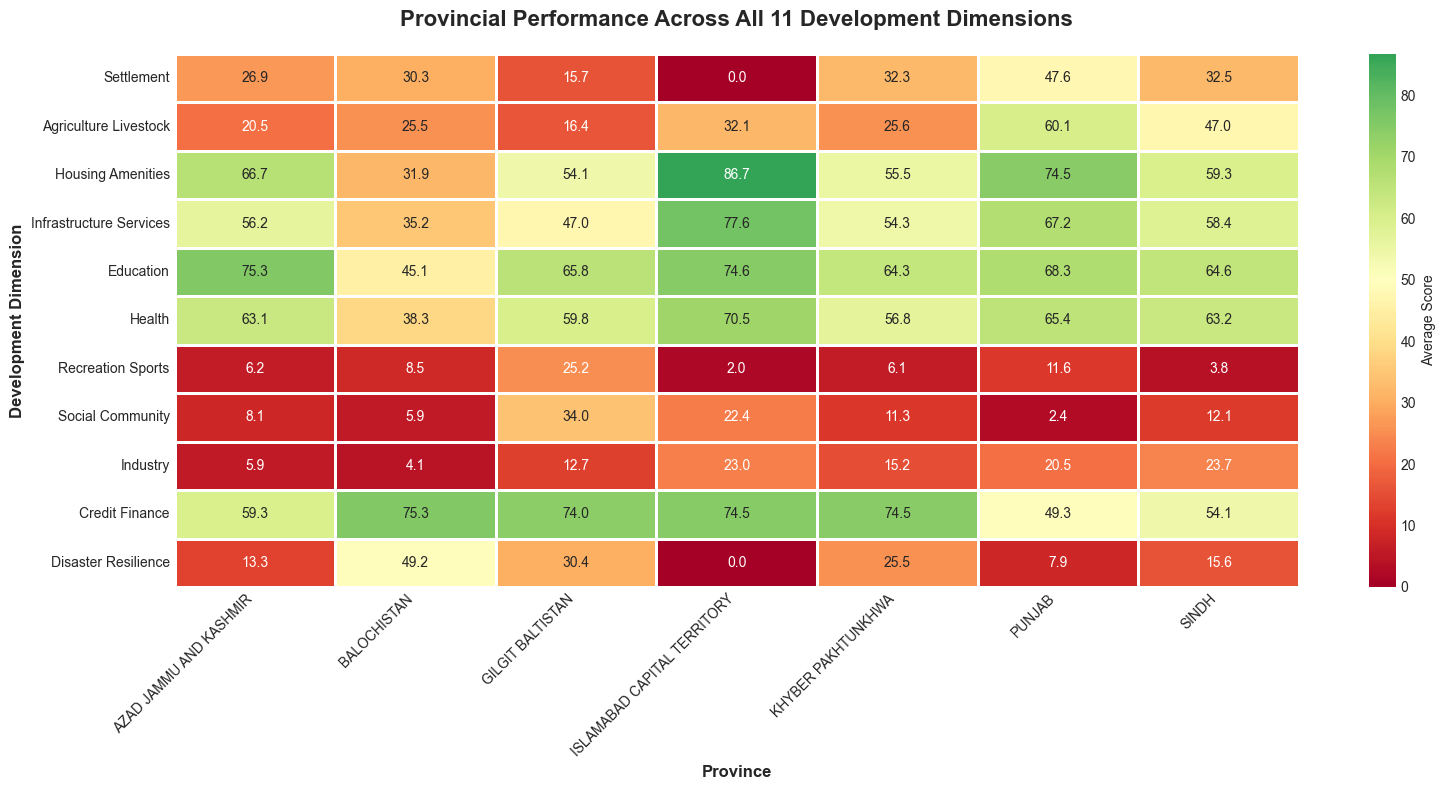


PROVINCIAL STRENGTHS AND WEAKNESSES

AZAD JAMMU AND KASHMIR:
  💪 Strongest: Education (Score: 75.3)
  ⚠️  Weakest: Industry (Score: 5.9)

BALOCHISTAN:
  💪 Strongest: Credit Finance (Score: 75.3)
  ⚠️  Weakest: Industry (Score: 4.1)

GILGIT BALTISTAN:
  💪 Strongest: Credit Finance (Score: 74.0)
  ⚠️  Weakest: Industry (Score: 12.7)

ISLAMABAD CAPITAL TERRITORY:
  💪 Strongest: Housing Amenities (Score: 86.7)
  ⚠️  Weakest: Settlement (Score: 0.0)

KHYBER PAKHTUNKHWA:
  💪 Strongest: Credit Finance (Score: 74.5)
  ⚠️  Weakest: Recreation Sports (Score: 6.1)

PUNJAB:
  💪 Strongest: Housing Amenities (Score: 74.5)
  ⚠️  Weakest: Social Community (Score: 2.4)

SINDH:
  💪 Strongest: Education (Score: 64.6)
  ⚠️  Weakest: Recreation Sports (Score: 3.8)

💡 KEY INSIGHT: Each province has unique strengths and weaknesses.
   Green cells = strong performance, Red cells = needs improvement

DEEPER ANALYSIS: Provincial Specialization & Comparative Advantage

AZAD JAMMU AND KASHMIR:
  📈 Comparative Ad

In [4]:
# Calculate provincial averages for all dimensions
province_indices = df.groupby('Name of Province')[index_cols].mean()
province_indices = province_indices.reindex(province_order)

# Heatmap showing all provinces across all dimensions
plt.figure(figsize=(16, 8))
sns.heatmap(province_indices.T, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=1, cbar_kws={'label': 'Average Score'},
            xticklabels=province_indices.index,
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Provincial Performance Across All 11 Development Dimensions', 
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Province', fontweight='bold', fontsize=12)
plt.ylabel('Development Dimension', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("PROVINCIAL STRENGTHS AND WEAKNESSES")
print("="*90)
for prov in province_indices.index:
    strongest = province_indices.loc[prov].idxmax().replace('_Index', '').replace('_', ' ')
    weakest = province_indices.loc[prov].idxmin().replace('_Index', '').replace('_', ' ')
    strongest_score = province_indices.loc[prov].max()
    weakest_score = province_indices.loc[prov].min()
    
    print(f"\n{prov}:")
    print(f"  💪 Strongest: {strongest} (Score: {strongest_score:.1f})")
    print(f"  ⚠️  Weakest: {weakest} (Score: {weakest_score:.1f})")

print("\n💡 KEY INSIGHT: Each province has unique strengths and weaknesses.")
print("   Green cells = strong performance, Red cells = needs improvement")

# Statistical Analysis: Calculate provincial specialization
from scipy import stats
print("\n" + "="*90)
print("DEEPER ANALYSIS: Provincial Specialization & Comparative Advantage")
print("="*90)

for prov in province_indices.index:
    scores = province_indices.loc[prov]
    # Calculate which dimensions this province performs RELATIVELY better in
    relative_performance = scores - province_indices.mean()
    top_advantages = relative_performance.nlargest(3)
    
    print(f"\n{prov}:")
    print(f"  📈 Comparative Advantages (vs national avg):")
    for dim, diff in top_advantages.items():
        dim_name = dim.replace('_Index', '').replace('_', ' ')
        print(f"     • {dim_name}: +{diff:.1f} points above avg")
    
    # Calculate coefficient of variation (consistency)
    cv = (scores.std() / scores.mean()) * 100
    consistency = "Very Consistent" if cv < 30 else "Moderate" if cv < 50 else "Highly Uneven"
    print(f"  📊 Development Balance: {consistency} (CV: {cv:.1f}%)")

## Q3: Let's look at each dimension individually - where do provinces stand?

We'll create bar charts for each of the 11 dimensions showing provincial rankings.

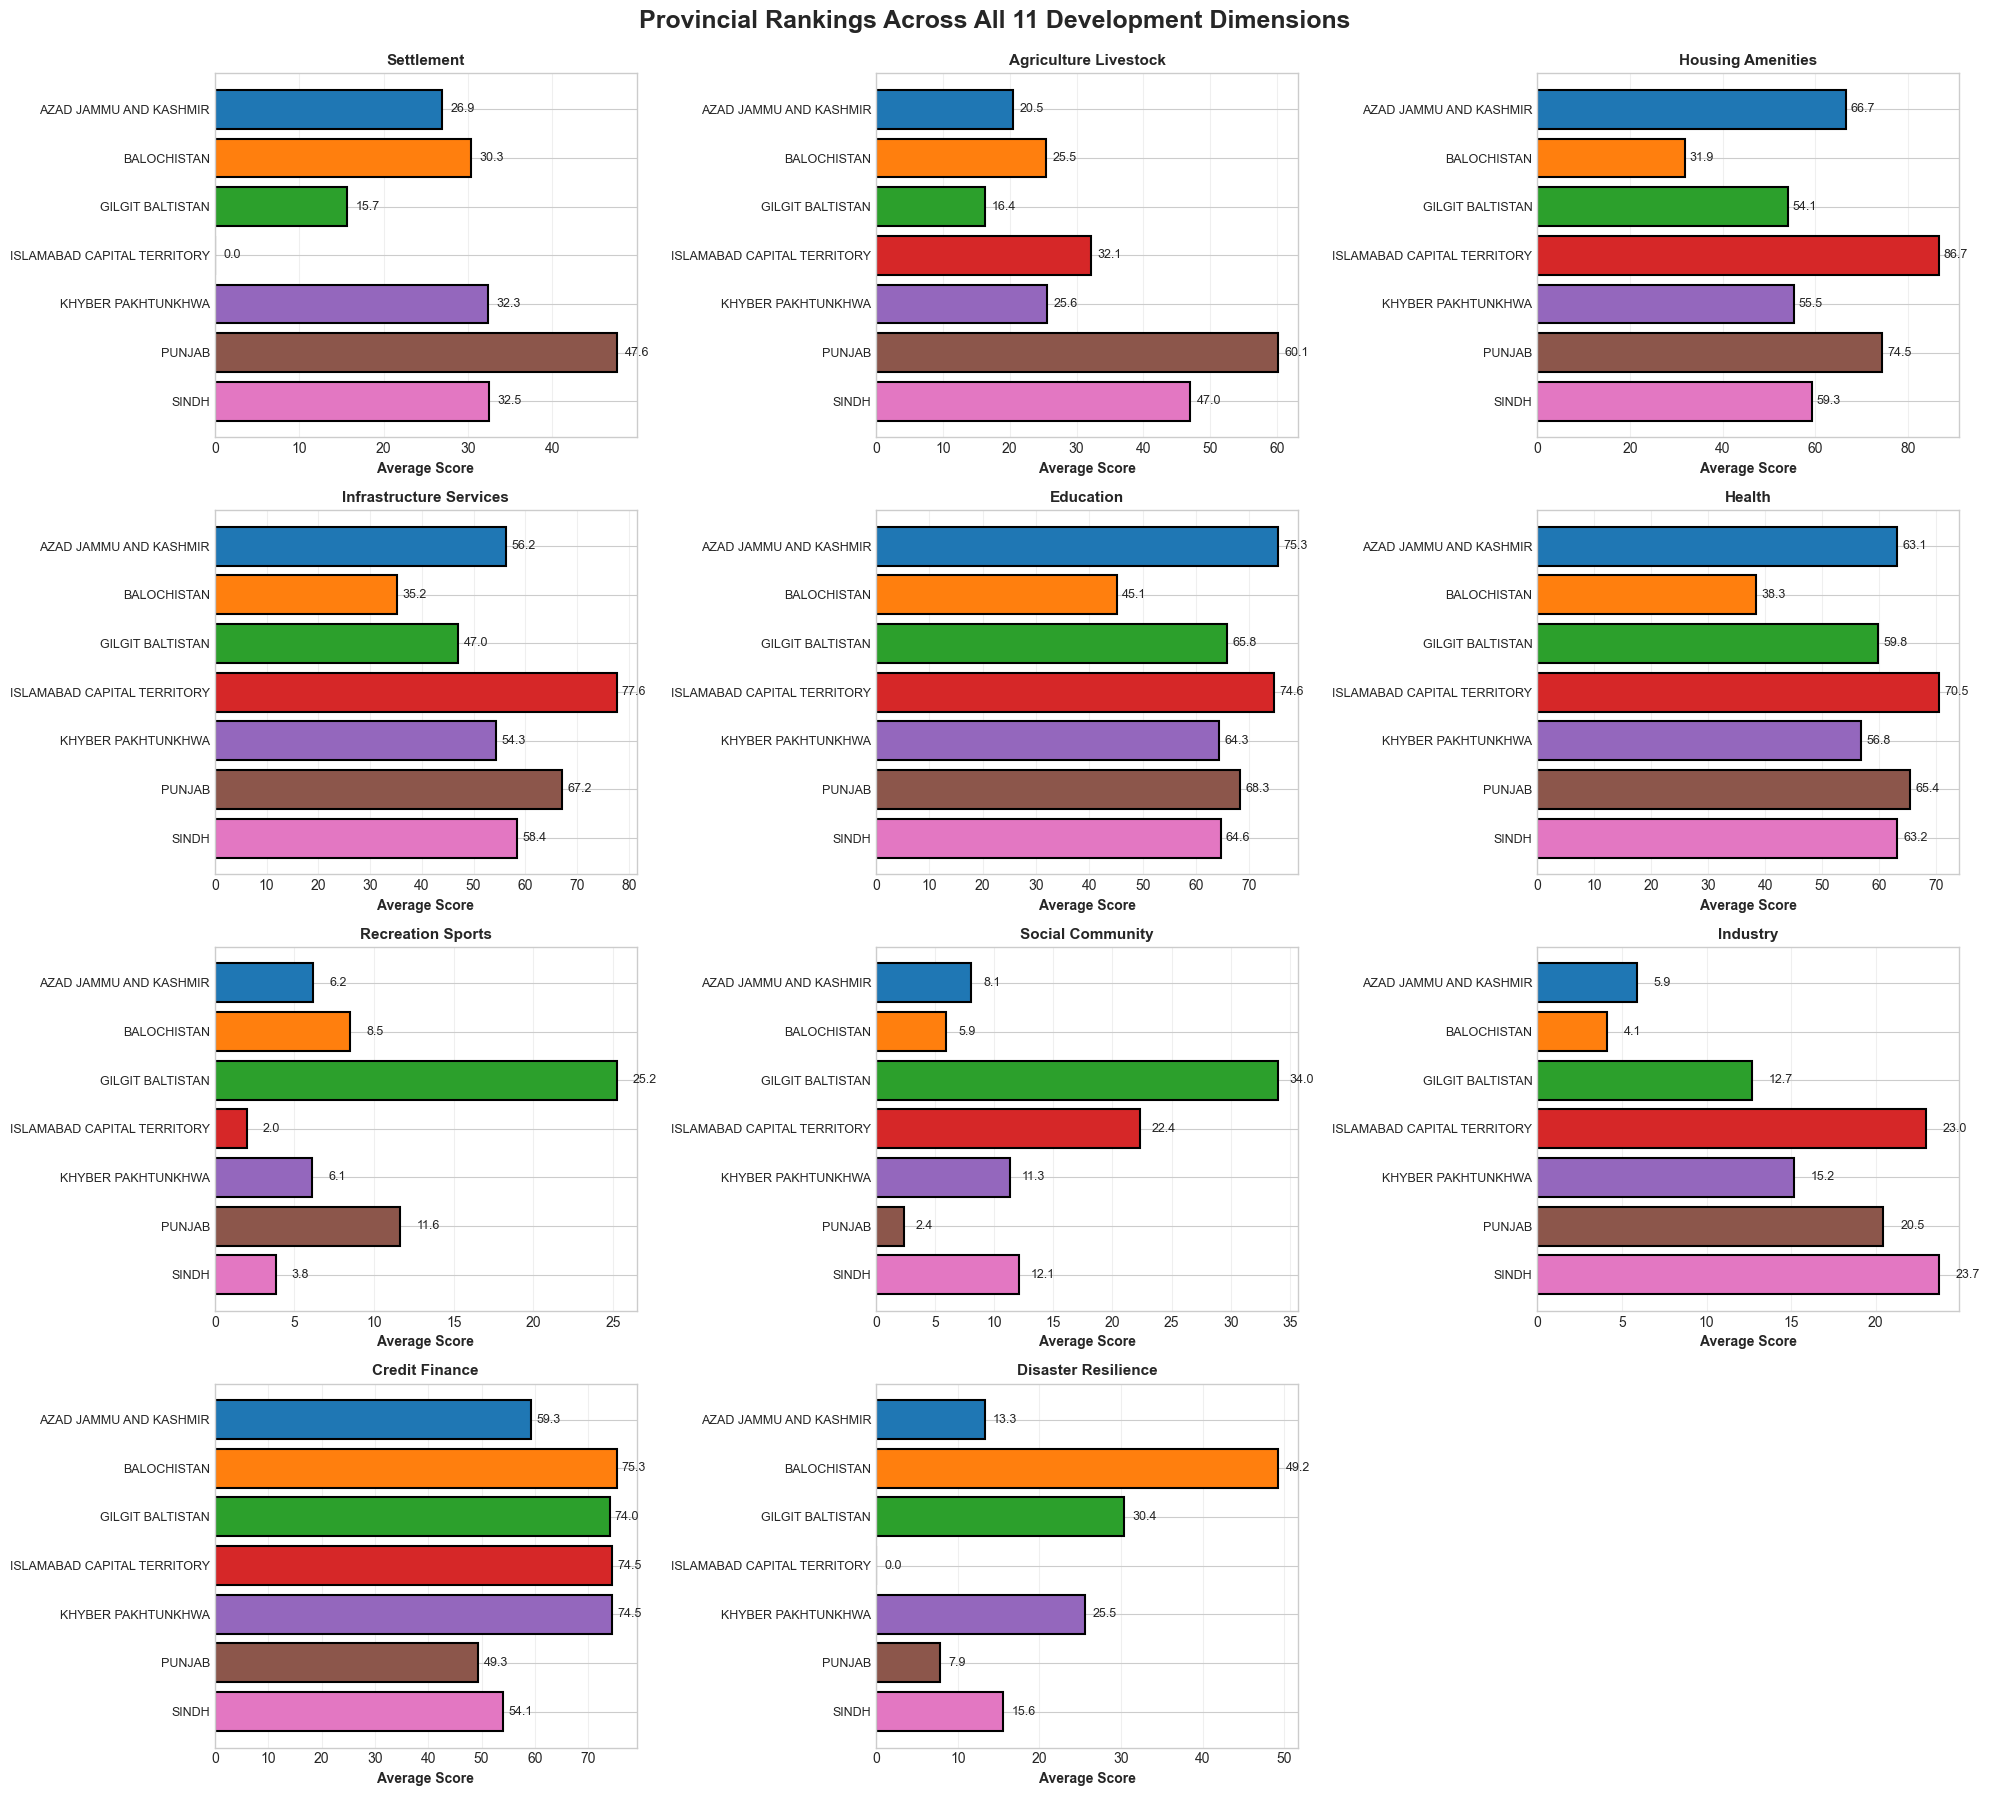


💡 KEY INSIGHT: Rankings vary by dimension - no province dominates everything.
   Each province has specific areas where it excels or struggles.


In [5]:
# Create individual bar charts for each dimension
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(index_cols):
    dimension_name = col.replace('_Index', '').replace('_', ' ')
    province_scores = df.groupby('Name of Province')[col].mean().reindex(province_order)
    
    # Use consistent province colors
    colors = [province_colors[prov] for prov in province_scores.index]
    
    axes[idx].barh(range(len(province_scores)), province_scores.values, 
                   color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_yticks(range(len(province_scores)))
    axes[idx].set_yticklabels(province_scores.index, fontsize=9)
    axes[idx].set_xlabel('Average Score', fontweight='bold', fontsize=10)
    axes[idx].set_title(dimension_name, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(province_scores.values):
        axes[idx].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

# Hide the last subplot if needed
if len(index_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Provincial Rankings Across All 11 Development Dimensions', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: Rankings vary by dimension - no province dominates everything.")
print("   Each province has specific areas where it excels or struggles.")

## Q4: How much variation exists within each dimension?

Let's see the distribution of district scores for each dimension using box plots.

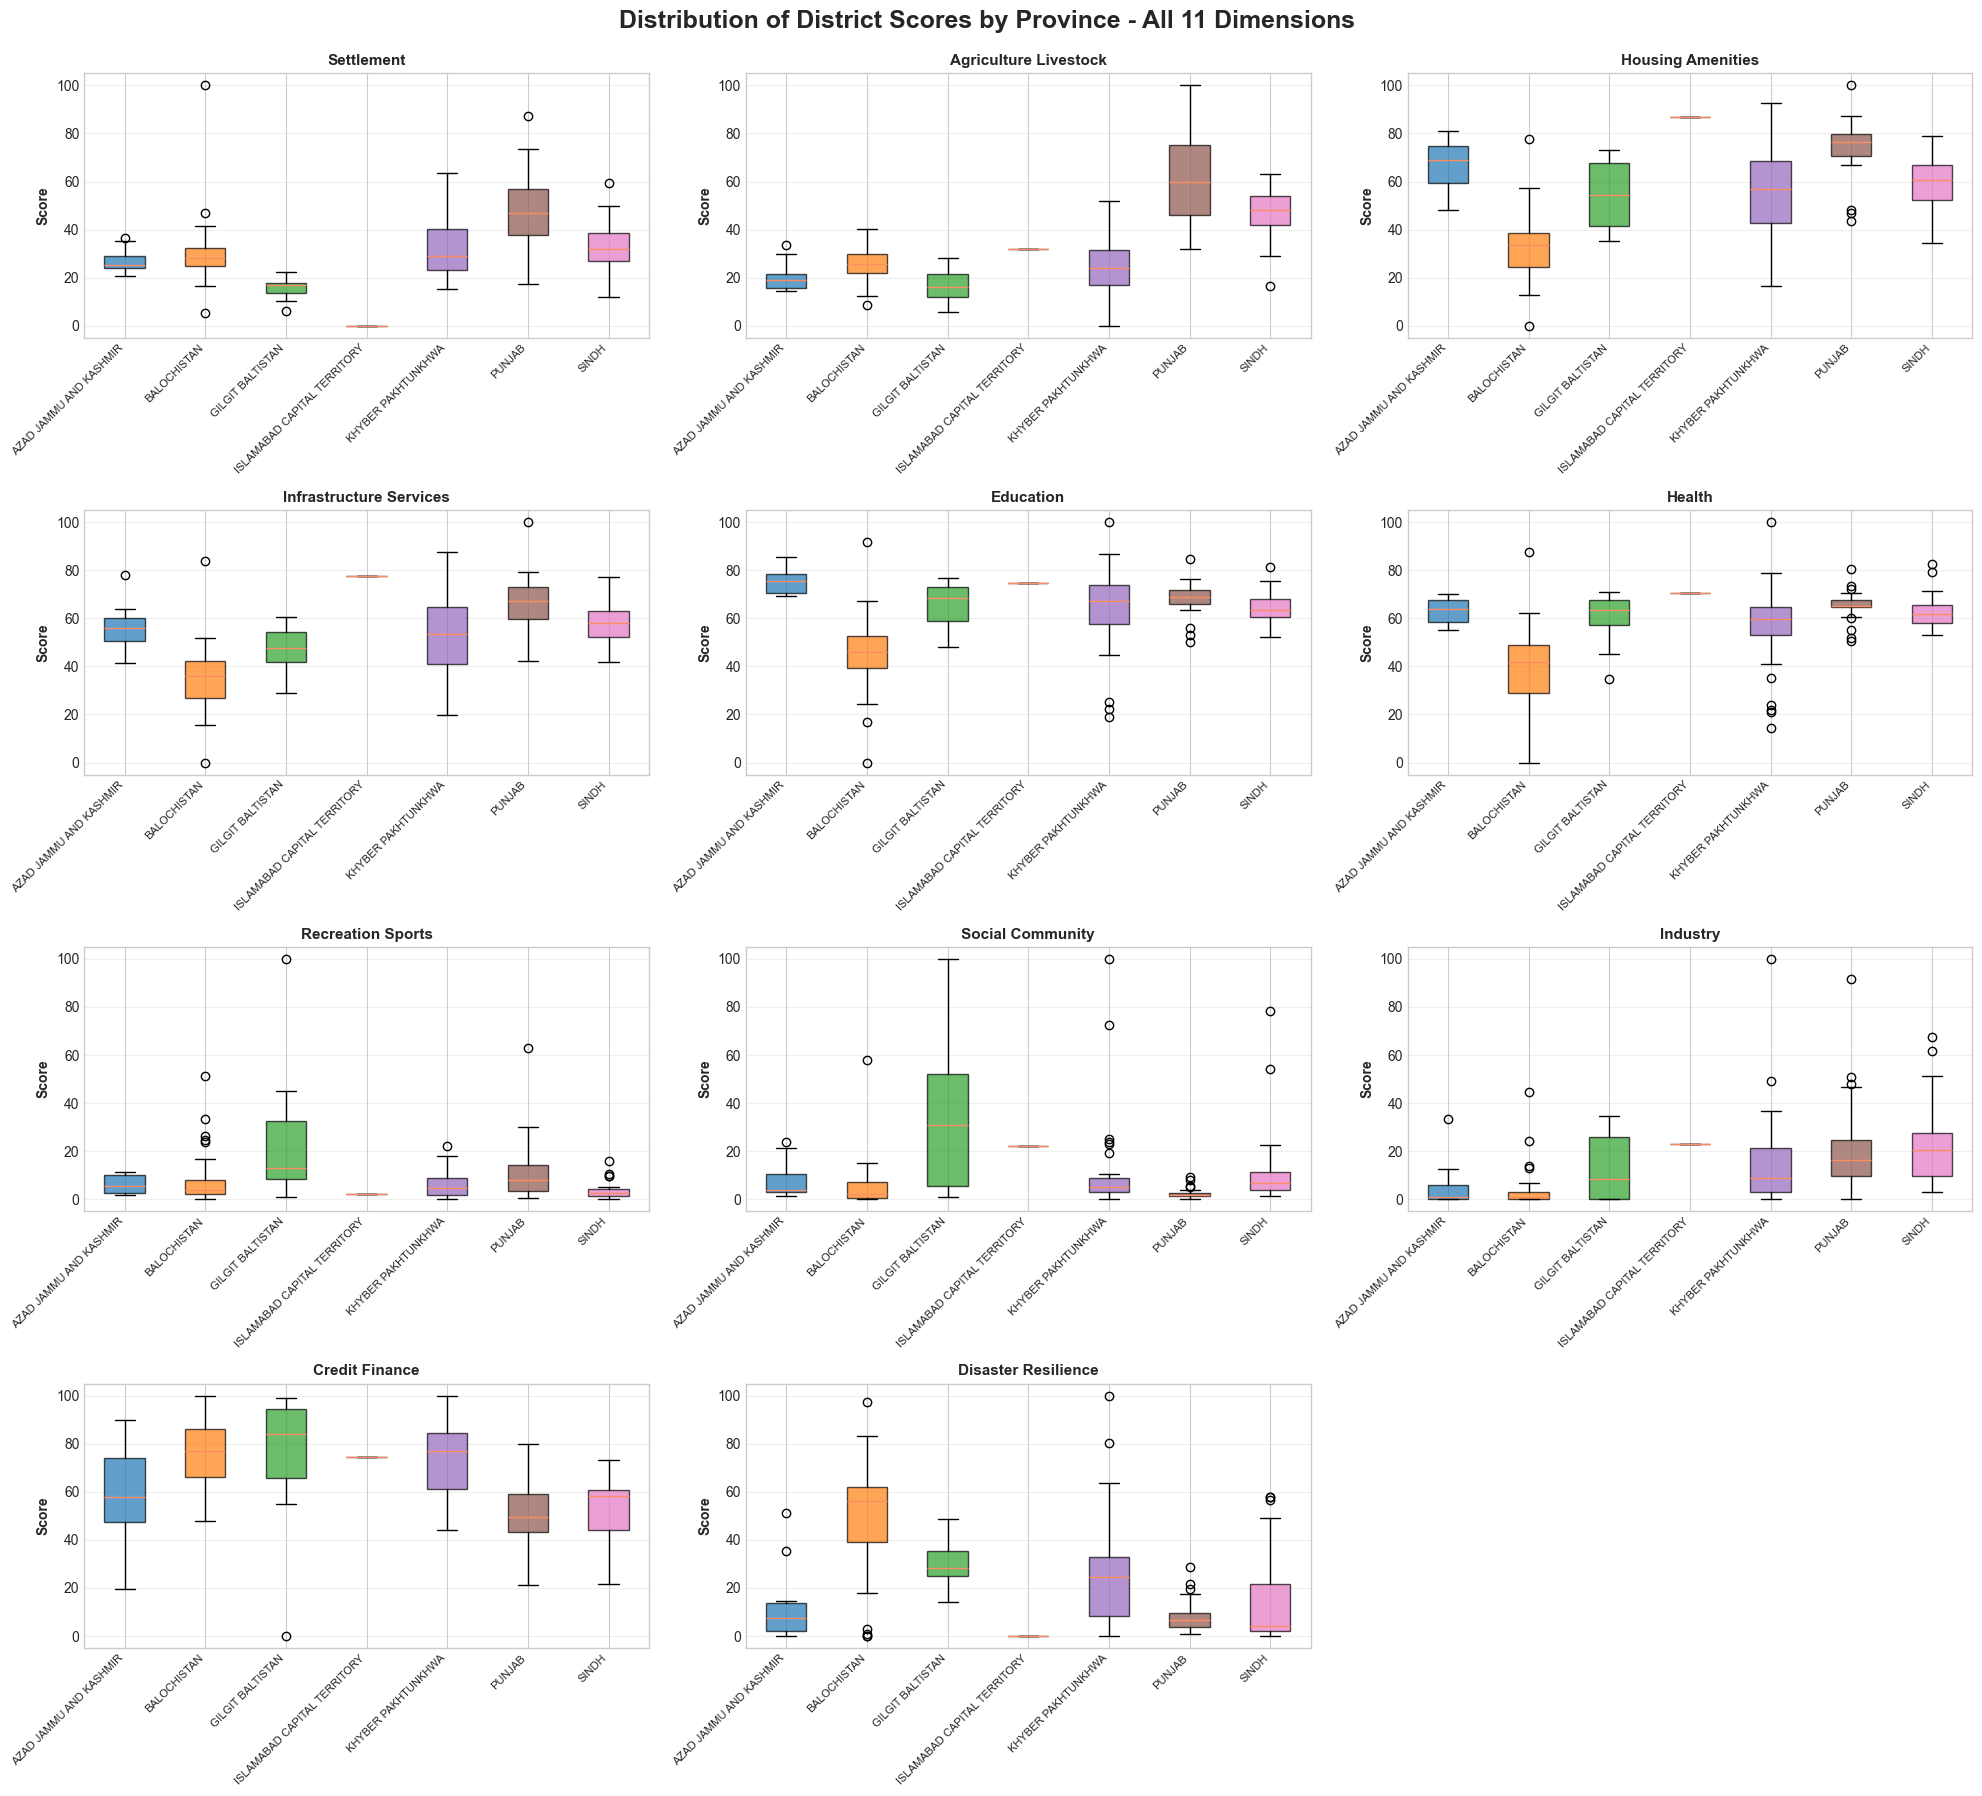


💡 KEY INSIGHT: Box plots show not just averages but the full range.
   Some provinces have wide variation (inconsistent districts), others are more uniform.


In [6]:
# Box plots for all 11 dimensions
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(index_cols):
    dimension_name = col.replace('_Index', '').replace('_', ' ')
    
    # Prepare data by province with consistent ordering
    province_data = []
    for prov in province_order:
        province_data.append(df[df['Name of Province'] == prov][col].values)
    
    bp = axes[idx].boxplot(province_data, labels=province_order, patch_artist=True)
    
    # Color boxes with consistent province colors
    for patch, prov in zip(bp['boxes'], province_order):
        patch.set_facecolor(province_colors[prov])
        patch.set_alpha(0.7)
    
    axes[idx].set_xticklabels(province_order, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Score', fontweight='bold', fontsize=10)
    axes[idx].set_title(dimension_name, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide the last subplot if needed
if len(index_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribution of District Scores by Province - All 11 Dimensions', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: Box plots show not just averages but the full range.")
print("   Some provinces have wide variation (inconsistent districts), others are more uniform.")

## Q5: Which dimensions show the biggest gaps between best and worst districts?

Understanding where inequality is highest helps prioritize interventions.


INEQUALITY ANALYSIS - WHERE ARE THE BIGGEST GAPS?



,Dimension,Highest District,Lowest District,Gap,National Average
0,Settlement,100.00,0.00,100.00,34.00
1,Agriculture Livestock,100.00,0.00,100.00,36.70
2,Housing Amenities,100.00,0.00,100.00,56.50
3,Infrastructure Services,100.00,0.00,100.00,53.80
4,Education,100.00,0.00,100.00,62.00
5,Health,100.00,0.00,100.00,56.60
6,Recreation Sports,100.00,0.00,100.00,8.90
7,Social Community,100.00,0.00,100.00,9.40
8,Industry,100.00,0.00,100.00,14.70
9,Credit Finance,100.00,0.00,100.00,64.10


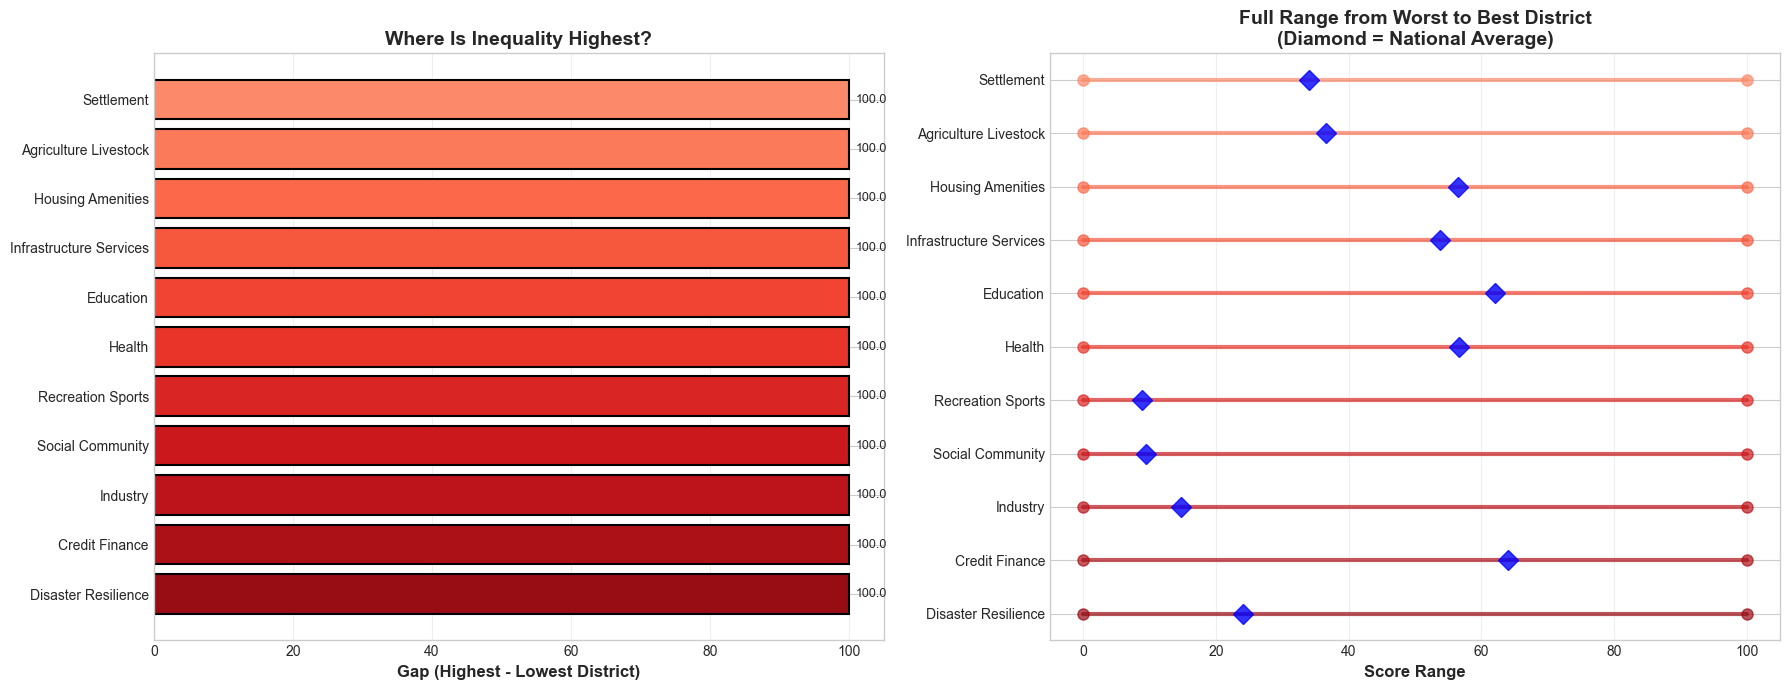


💡 KEY INSIGHTS:
   • Highest inequality: Settlement (100.0 point gap)
   • Most uniform: Disaster Resilience (100.0 point gap)
   • Focus on high-gap dimensions for equity improvements

ACTIONABLE INSIGHT: Priority Dimensions (High Inequality + Low Performance)

These dimensions need URGENT attention (high inequality + low scores):

  🔴 CRITICAL: Recreation Sports
     Gap: 100.0 points | National Avg: 8.9
     Why urgent: Very low scores + high disparity = many districts struggling
     Impact: 0 districts (0%) are severely behind

  🔴 CRITICAL: Social Community
     Gap: 100.0 points | National Avg: 9.4
     Why urgent: Very low scores + high disparity = many districts struggling
     Impact: 0 districts (0%) are severely behind

  🔴 CRITICAL: Industry
     Gap: 100.0 points | National Avg: 14.7
     Why urgent: Very low scores + high disparity = many districts struggling
     Impact: 53 districts (35%) are severely behind

  🔴 CRITICAL: Disaster Resilience
     Gap: 100.0 points | 

In [7]:
# Calculate gap metrics for each dimension
gap_analysis = []
for col in index_cols:
    dimension_name = col.replace('_Index', '').replace('_', ' ')
    gap_analysis.append({
        'Dimension': dimension_name,
        'Highest District': df[col].max(),
        'Lowest District': df[col].min(),
        'Gap': df[col].max() - df[col].min(),
        'National Average': df[col].mean()
    })

gap_df = pd.DataFrame(gap_analysis).sort_values('Gap', ascending=False)

print("\n" + "="*90)
print("INEQUALITY ANALYSIS - WHERE ARE THE BIGGEST GAPS?")
print("="*90)
print()
display(gap_df.round(1))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gap ranking
colors_gap = plt.cm.Reds(np.linspace(0.4, 0.9, len(gap_df)))
ax1.barh(range(len(gap_df)), gap_df['Gap'], color=colors_gap, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(gap_df)))
ax1.set_yticklabels(gap_df['Dimension'], fontsize=10)
ax1.set_xlabel('Gap (Highest - Lowest District)', fontweight='bold', fontsize=12)
ax1.set_title('Where Is Inequality Highest?', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Add gap values
for i, row in enumerate(gap_df.itertuples()):
    ax1.text(row.Gap + 1, i, f'{row.Gap:.1f}', va='center', fontsize=9)

# Range visualization (min to max for each dimension)
for idx, row in gap_df.iterrows():
    ax2.plot([row['Lowest District'], row['Highest District']], [idx, idx], 
             'o-', linewidth=3, markersize=8, alpha=0.7, color=colors_gap[idx])
    ax2.plot(row['National Average'], idx, 'D', markersize=10, color='blue', alpha=0.8)

ax2.set_yticks(range(len(gap_df)))
ax2.set_yticklabels(gap_df['Dimension'], fontsize=10)
ax2.set_xlabel('Score Range', fontweight='bold', fontsize=12)
ax2.set_title('Full Range from Worst to Best District\n(Diamond = National Average)', 
              fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHTS:")
print(f"   • Highest inequality: {gap_df.iloc[0]['Dimension']} ({gap_df.iloc[0]['Gap']:.1f} point gap)")
print(f"   • Most uniform: {gap_df.iloc[-1]['Dimension']} ({gap_df.iloc[-1]['Gap']:.1f} point gap)")
print(f"   • Focus on high-gap dimensions for equity improvements")

# Deeper Analysis: Inequality + Low Performance = Priority Areas
print("\n" + "="*90)
print("ACTIONABLE INSIGHT: Priority Dimensions (High Inequality + Low Performance)")
print("="*90)
gap_df['Priority_Score'] = gap_df['Gap'] * (100 - gap_df['National Average'])
gap_df_priority = gap_df.sort_values('Priority_Score', ascending=False)

print("\nThese dimensions need URGENT attention (high inequality + low scores):")
for idx, row in gap_df_priority.head(5).iterrows():
    urgency = "🔴 CRITICAL" if row['National Average'] < 30 else "🟠 HIGH" if row['National Average'] < 50 else "🟡 MEDIUM"
    print(f"\n  {urgency}: {row['Dimension']}")
    print(f"     Gap: {row['Gap']:.1f} points | National Avg: {row['National Average']:.1f}")
    print(f"     Why urgent: {'Very low scores + high disparity = many districts struggling' if row['National Average'] < 30 else 'Moderate scores but massive inequality'}")
    
    # Calculate how many districts are severely underperforming
    col_name = [c for c in index_cols if row['Dimension'] in c.replace('_Index', '').replace('_', ' ')][0]
    struggling = len(df[df[col_name] < row['National Average'] - 10])
    print(f"     Impact: {struggling} districts ({struggling/len(df)*100:.0f}%) are severely behind")

---
# 🏆 PART 3: Overall Performance - Champions & Strugglers

Now that we understand individual dimensions, let's look at overall development (average across all 11 dimensions).

## Q6: Which are the top performing districts overall?


🏆 TOP 20 DISTRICTS - PAKISTAN'S DEVELOPMENT CHAMPIONS

  17. MALAKAND PROTECTED AREA        (KHYBER PAKHTUNKHWA  ) - Score: 58.5
  145. LAHORE DISTRICT                (PUNJAB              ) - Score: 56.7
  130. HUNZA DISTRICT                 (GILGIT BALTISTAN    ) - Score: 54.1
  35. FAISALABAD DISTRICT            (PUNJAB              ) - Score: 53.0
  15. CHITRAL UPPER                  (KHYBER PAKHTUNKHWA  ) - Score: 51.7
  143. MALIR DISTRICT                 (SINDH               ) - Score: 51.4
  37. TOBA TEK SINGH DISTRICT        (PUNJAB              ) - Score: 50.2
  21. MARDAN DISTRICT                (KHYBER PAKHTUNKHWA  ) - Score: 48.9
  49. MULTAN DISTRICT                (PUNJAB              ) - Score: 48.7
  128. GHIZER DISTRICT                (GILGIT BALTISTAN    ) - Score: 47.9
  43. SIALKOT DISTRICT               (PUNJAB              ) - Score: 47.7
  61. SARGODHA DISTRICT              (PUNJAB              ) - Score: 47.6
  38. GUJRANWALA DISTRICT            (PUNJAB        

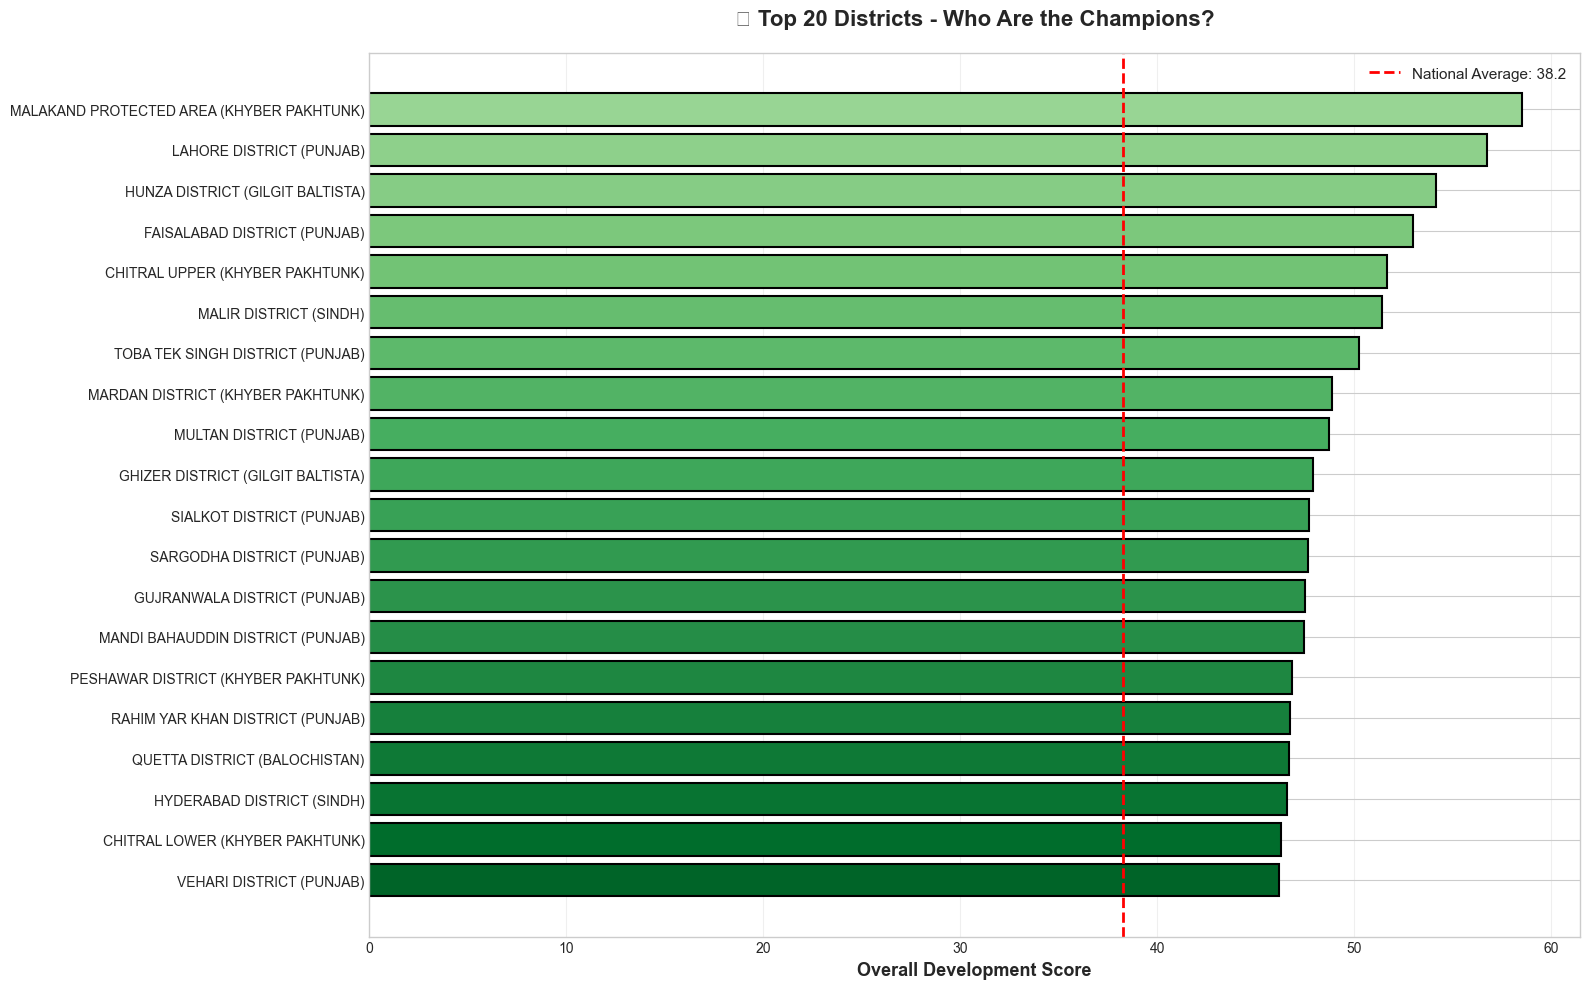


💡 KEY INSIGHT: The best district (MALAKAND PROTECTED AREA) scores 58.5,
   which is 20.3 points above the national average.


In [8]:
# Top 20 performing districts
top_20 = df.nlargest(20, 'Composite_Score')[['Name of District', 'Name of Province', 'Name of Division', 'Composite_Score']]

print("\n" + "="*90)
print("🏆 TOP 20 DISTRICTS - PAKISTAN'S DEVELOPMENT CHAMPIONS")
print("="*90)
print()
for i, row in top_20.iterrows():
    print(f"  {row.name+1:2d}. {row['Name of District']:30s} ({row['Name of Province']:20s}) - Score: {row['Composite_Score']:.1f}")

# Visualization
plt.figure(figsize=(16, 10))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_20)))
plt.barh(range(len(top_20)), top_20['Composite_Score'], color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(top_20)), 
           [f"{row['Name of District'][:25]} ({row['Name of Province'][:15]})" 
            for _, row in top_20.iterrows()], fontsize=10)
plt.xlabel('Overall Development Score', fontweight='bold', fontsize=13)
plt.title('🏆 Top 20 Districts - Who Are the Champions?', fontweight='bold', fontsize=16, pad=20)
plt.axvline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'National Average: {df["Composite_Score"].mean():.1f}')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The best district ({top_20.iloc[0]['Name of District']}) scores {top_20.iloc[0]['Composite_Score']:.1f},")
print(f"   which is {top_20.iloc[0]['Composite_Score'] - df['Composite_Score'].mean():.1f} points above the national average.")

## Q2: What about the districts that need the most support?


⚠️  BOTTOM 20 DISTRICTS - WHERE SUPPORT IS MOST NEEDED

  106. KOHLU DISTRICT                 (BALOCHISTAN         ) - Score: 19.1
  151. KOLAI PALAS KOHISTAN           (KHYBER PAKHTUNKHWA  ) - Score: 22.4
  149. KOHISTAN DISTRICT              (KHYBER PAKHTUNKHWA  ) - Score: 24.1
  115. ZHOB DISTRICT                  (BALOCHISTAN         ) - Score: 25.3
  84. AWARAN DISTRICT                (BALOCHISTAN         ) - Score: 25.8
  112. DUKI DISTRICT                  (BALOCHISTAN         ) - Score: 26.0
  91. WASHUK DISTRICT                (BALOCHISTAN         ) - Score: 26.2
  88. KHUZDAR DISTRICT               (BALOCHISTAN         ) - Score: 26.5
  92. GWADAR DISTRICT                (BALOCHISTAN         ) - Score: 26.5
  113. MUSAKHEL DISTRICT              (BALOCHISTAN         ) - Score: 26.9
  85. KALAT DISTRICT                 (BALOCHISTAN         ) - Score: 27.0
  114. SHERANI DISTRICT               (BALOCHISTAN         ) - Score: 27.8
  150. LOWER KOHISTAN                 (KHYBER PA

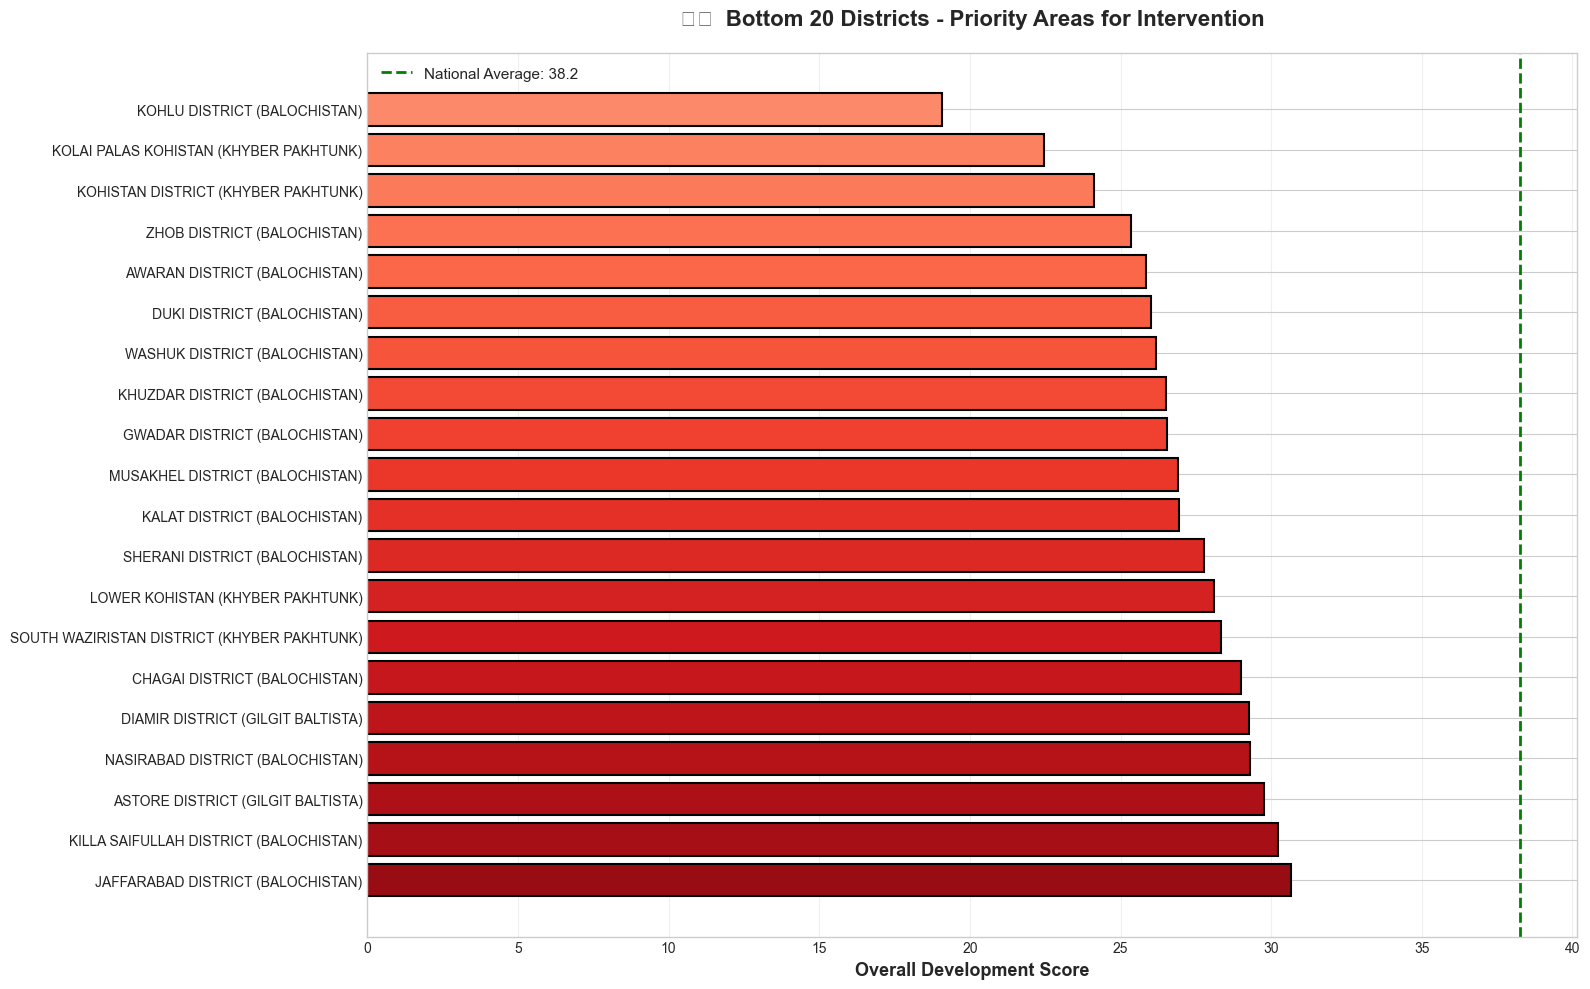


💡 KEY INSIGHT: There's a 39.4 point gap between the best and worst performing districts.
   This represents significant inequality in development across Pakistan.


In [9]:
# Bottom 20 districts
bottom_20 = df.nsmallest(20, 'Composite_Score')[['Name of District', 'Name of Province', 'Name of Division', 'Composite_Score']]

print("\n" + "="*90)
print("⚠️  BOTTOM 20 DISTRICTS - WHERE SUPPORT IS MOST NEEDED")
print("="*90)
print()
for i, row in bottom_20.iterrows():
    print(f"  {row.name+1:2d}. {row['Name of District']:30s} ({row['Name of Province']:20s}) - Score: {row['Composite_Score']:.1f}")

# Visualization
plt.figure(figsize=(16, 10))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(bottom_20)))
plt.barh(range(len(bottom_20)), bottom_20['Composite_Score'], color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(bottom_20)), 
           [f"{row['Name of District'][:25]} ({row['Name of Province'][:15]})" 
            for _, row in bottom_20.iterrows()], fontsize=10)
plt.xlabel('Overall Development Score', fontweight='bold', fontsize=13)
plt.title('⚠️  Bottom 20 Districts - Priority Areas for Intervention', fontweight='bold', fontsize=16, pad=20)
plt.axvline(df['Composite_Score'].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'National Average: {df["Composite_Score"].mean():.1f}')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

gap = top_20.iloc[0]['Composite_Score'] - bottom_20.iloc[0]['Composite_Score']
print(f"\n💡 KEY INSIGHT: There's a {gap:.1f} point gap between the best and worst performing districts.")
print(f"   This represents significant inequality in development across Pakistan.")

## Q3: How are all 153 districts distributed across the development spectrum?

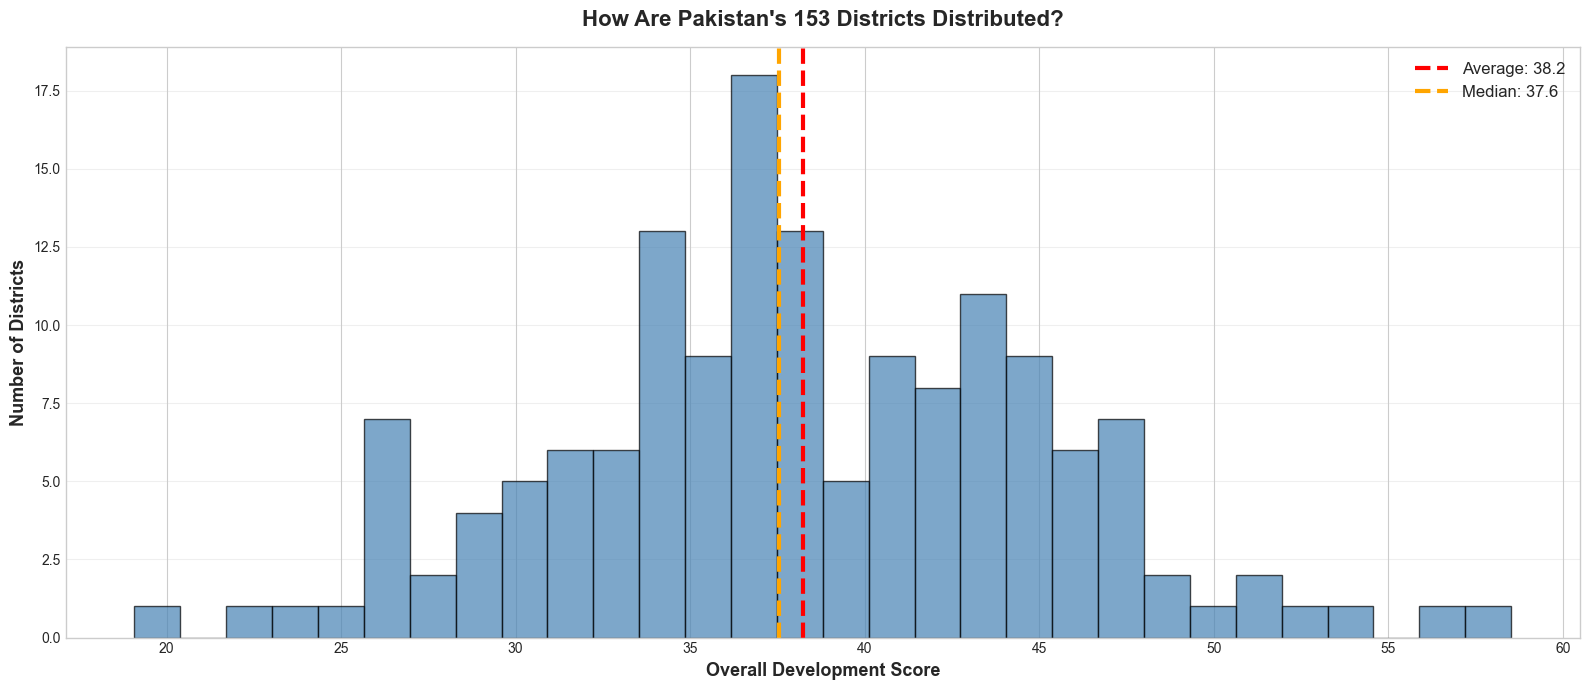


📊 DISTRICT DISTRIBUTION:
   • 127 districts (84.1%) score below 45 (Low development)
   • 22 districts (14.6%) score 45-55 (Medium development)
   • 2 districts (1.3%) score above 55 (High development)


In [10]:
# Overall distribution
plt.figure(figsize=(16, 7))
plt.hist(df['Composite_Score'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=3, 
            label=f'Average: {df["Composite_Score"].mean():.1f}')
plt.axvline(df['Composite_Score'].median(), color='orange', linestyle='--', linewidth=3, 
            label=f'Median: {df["Composite_Score"].median():.1f}')
plt.xlabel('Overall Development Score', fontweight='bold', fontsize=13)
plt.ylabel('Number of Districts', fontweight='bold', fontsize=13)
plt.title('How Are Pakistan\'s 153 Districts Distributed?', fontweight='bold', fontsize=16, pad=15)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Count districts in different ranges
low = len(df[df['Composite_Score'] < 45])
medium = len(df[(df['Composite_Score'] >= 45) & (df['Composite_Score'] < 55)])
high = len(df[df['Composite_Score'] >= 55])

print(f"\n📊 DISTRICT DISTRIBUTION:")
print(f"   • {low} districts ({low/len(df)*100:.1f}%) score below 45 (Low development)")
print(f"   • {medium} districts ({medium/len(df)*100:.1f}%) score 45-55 (Medium development)")
print(f"   • {high} districts ({high/len(df)*100:.1f}%) score above 55 (High development)")

---
# 🎯 PART 3: What Drives Success?

Now that we know who's doing well, let's understand WHY by looking at which development areas matter most.

## Q4: Which development dimensions are most important for overall success?


🎯 WHICH DEVELOPMENT AREAS MATTER MOST?

Importance Ranking (using machine learning analysis):

   3. Housing Amenities                   ██████████████████████ 0.225
   4. Infrastructure Services             █████████████████ 0.173
   6. Health                              ████████████████ 0.168
   9. Industry                            ███████████████ 0.159
   5. Education                           ████████ 0.081
   7. Recreation Sports                   ███████ 0.070
   8. Social Community                    ███ 0.039
  11. Disaster Resilience                 ██ 0.027
   1. Settlement                          ██ 0.021
   2. Agriculture Livestock               █ 0.020
  10. Credit Finance                      █ 0.017


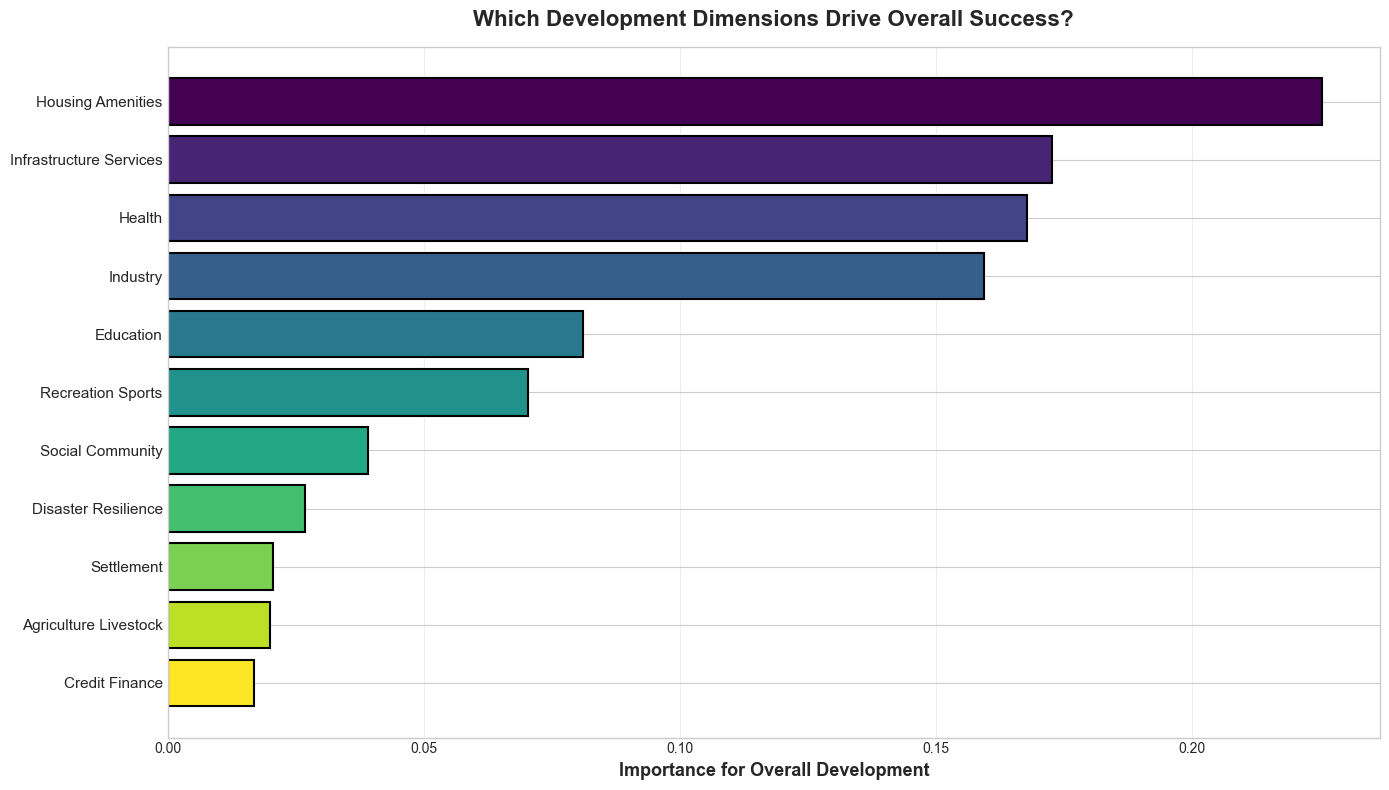


💡 KEY INSIGHT: The top 3 drivers of overall development are:
   3. Housing Amenities
   4. Infrastructure Services
   6. Health
   Focus on these areas can have the biggest impact on overall development.


In [11]:
# Use Random Forest to identify which dimensions drive overall development
X = df[index_cols]
y = df['Composite_Score']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Dimension': [col.replace('_Index', '').replace('_', ' ') for col in index_cols],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*90)
print("🎯 WHICH DEVELOPMENT AREAS MATTER MOST?")
print("="*90)
print("\nImportance Ranking (using machine learning analysis):\n")
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {i+1:2d}. {row['Dimension']:35s} {bar} {row['Importance']:.3f}")

# Visualization
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
plt.barh(range(len(importance_df)), importance_df['Importance'], 
         color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(importance_df)), importance_df['Dimension'], fontsize=11)
plt.xlabel('Importance for Overall Development', fontweight='bold', fontsize=13)
plt.title('Which Development Dimensions Drive Overall Success?', fontweight='bold', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The top 3 drivers of overall development are:")
for i, row in importance_df.head(3).iterrows():
    print(f"   {i+1}. {row['Dimension']}")
print("   Focus on these areas can have the biggest impact on overall development.")

## Q5: How do top performers compare to bottom performers across these dimensions?


TOP 10 vs BOTTOM 10 DISTRICTS - WHERE ARE THE BIGGEST GAPS?



,Dimension,Top 10 Avg,Bottom 10 Avg,Gap
2,Housing Amenities,76.00,19.00,57.00
4,Education,77.00,27.30,49.60
3,Infrastructure Services,71.80,22.40,49.40
5,Health,72.20,23.90,48.20
8,Industry,46.90,1.70,45.20
7,Social Community,36.50,3.40,33.00
6,Recreation Sports,32.90,3.10,29.80
1,Agriculture Livestock,48.10,19.00,29.10
0,Settlement,28.00,37.70,-9.70
9,Credit Finance,62.00,75.50,-13.40


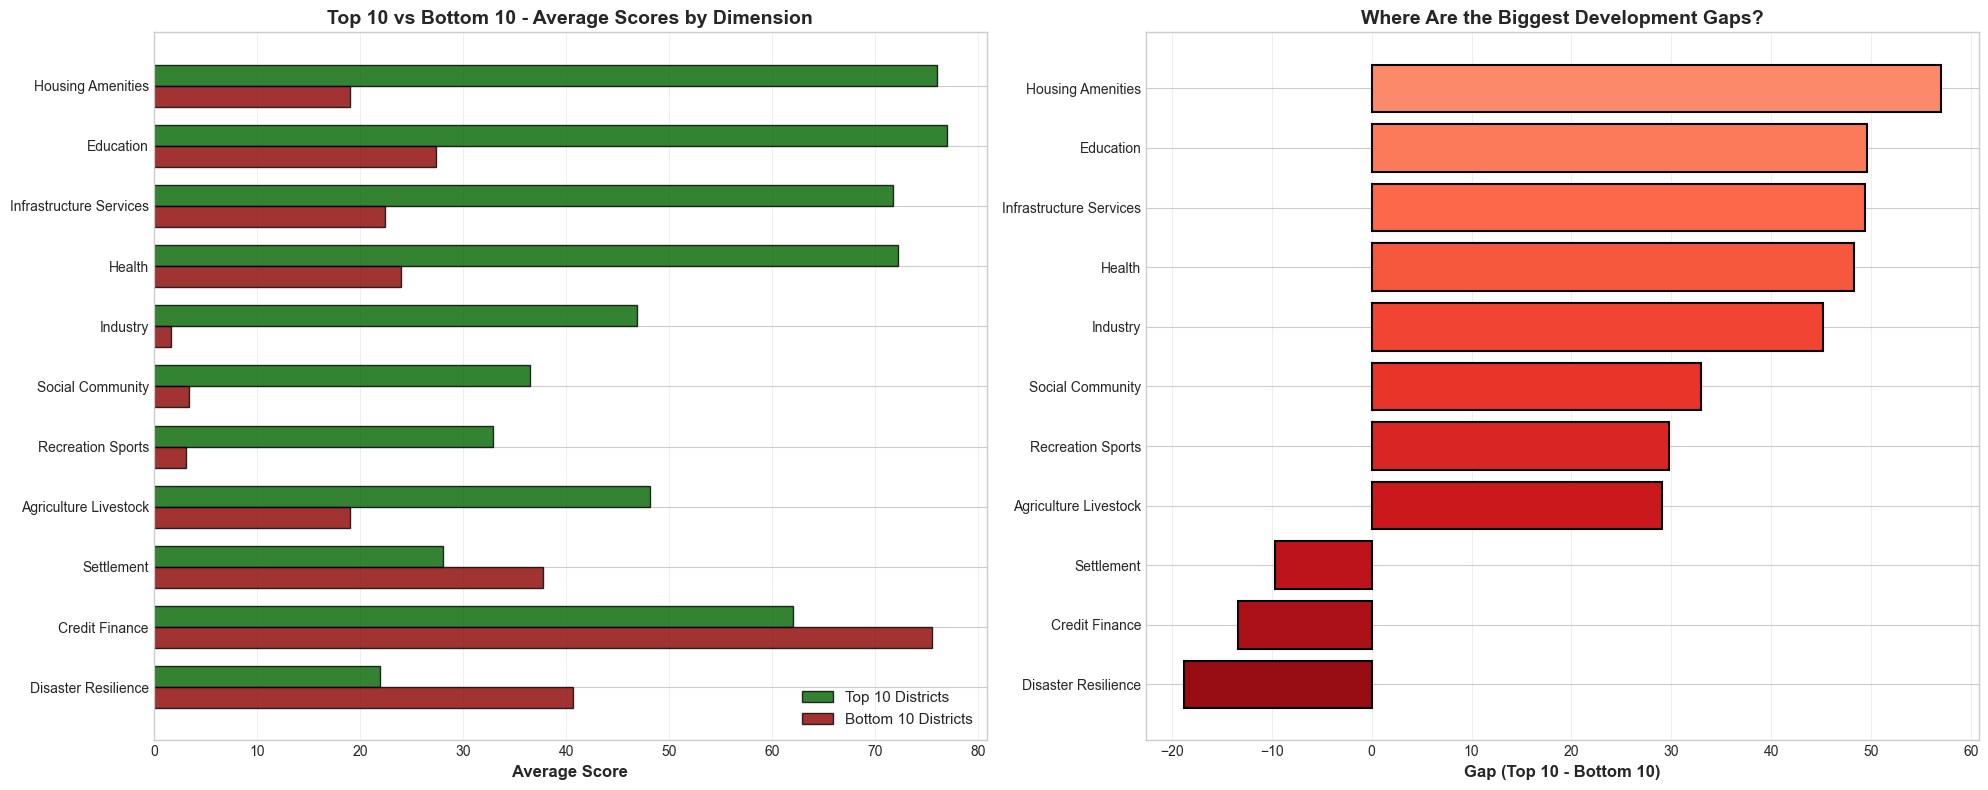


💡 KEY INSIGHT: The biggest gap is in Housing Amenities (57.0 points)
   This is where top and bottom performers differ most dramatically.


In [12]:
# Compare top 10 vs bottom 10
top_10_avg = df.nlargest(10, 'Composite_Score')[index_cols].mean()
bottom_10_avg = df.nsmallest(10, 'Composite_Score')[index_cols].mean()
difference = top_10_avg - bottom_10_avg

comparison_df = pd.DataFrame({
    'Dimension': [col.replace('_Index', '').replace('_', ' ') for col in index_cols],
    'Top 10 Avg': top_10_avg.values,
    'Bottom 10 Avg': bottom_10_avg.values,
    'Gap': difference.values
}).sort_values('Gap', ascending=False)

print("\n" + "="*90)
print("TOP 10 vs BOTTOM 10 DISTRICTS - WHERE ARE THE BIGGEST GAPS?")
print("="*90)
print()
display(comparison_df.round(1))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

x = np.arange(len(comparison_df))
width = 0.35

ax1.barh(x - width/2, comparison_df['Top 10 Avg'], width, label='Top 10 Districts', 
         color='darkgreen', alpha=0.8, edgecolor='black')
ax1.barh(x + width/2, comparison_df['Bottom 10 Avg'], width, label='Bottom 10 Districts', 
         color='darkred', alpha=0.8, edgecolor='black')
ax1.set_yticks(x)
ax1.set_yticklabels(comparison_df['Dimension'], fontsize=10)
ax1.set_xlabel('Average Score', fontweight='bold', fontsize=12)
ax1.set_title('Top 10 vs Bottom 10 - Average Scores by Dimension', fontweight='bold', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Gap visualization
colors_gap = plt.cm.Reds(np.linspace(0.4, 0.9, len(comparison_df)))
ax2.barh(range(len(comparison_df)), comparison_df['Gap'], color=colors_gap, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(comparison_df)))
ax2.set_yticklabels(comparison_df['Dimension'], fontsize=10)
ax2.set_xlabel('Gap (Top 10 - Bottom 10)', fontweight='bold', fontsize=12)
ax2.set_title('Where Are the Biggest Development Gaps?', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The biggest gap is in {comparison_df.iloc[0]['Dimension']} ({comparison_df.iloc[0]['Gap']:.1f} points)")
print(f"   This is where top and bottom performers differ most dramatically.")

## Q6: Are different development areas related to each other?

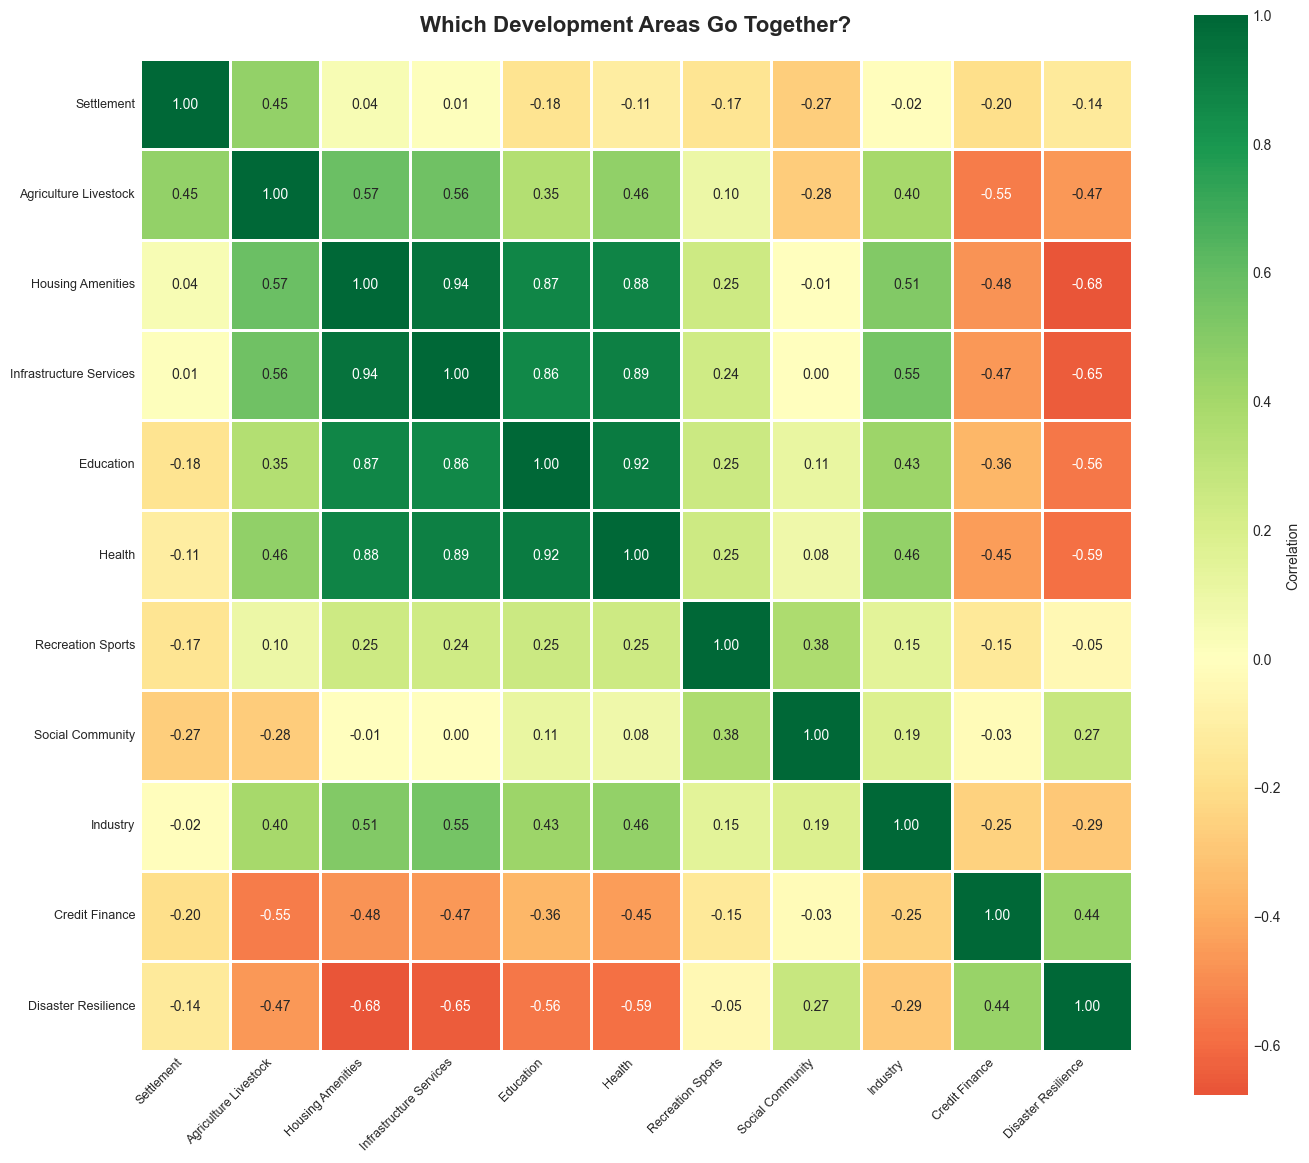


STRONGEST RELATIONSHIPS BETWEEN DEVELOPMENT AREAS

Top 5 pairs that tend to go together:

  1. Infrastructure Services ↔ Housing Amenities
     Correlation: 0.94 (Strong positive relationship)

  2. Health ↔ Education
     Correlation: 0.92 (Strong positive relationship)

  3. Health ↔ Infrastructure Services
     Correlation: 0.89 (Strong positive relationship)

  4. Health ↔ Housing Amenities
     Correlation: 0.88 (Strong positive relationship)

  5. Education ↔ Housing Amenities
     Correlation: 0.87 (Strong positive relationship)

💡 KEY INSIGHT: When districts score high in one area, they often score high in related areas.
   This suggests development in one sector can positively influence others.


In [13]:
# Correlation analysis
corr_matrix = df[index_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, 
            xticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols],
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Which Development Areas Go Together?', fontweight='bold', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Find strongest correlations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_no_diag = corr_matrix.mask(mask)
correlations = corr_no_diag.stack().sort_values(ascending=False)

print("\n" + "="*90)
print("STRONGEST RELATIONSHIPS BETWEEN DEVELOPMENT AREAS")
print("="*90)
print("\nTop 5 pairs that tend to go together:\n")
for i, (pair, corr) in enumerate(correlations.head(5).items(), 1):
    dim1 = pair[0].replace('_Index', '').replace('_', ' ')
    dim2 = pair[1].replace('_Index', '').replace('_', ' ')
    print(f"  {i}. {dim1} ↔ {dim2}")
    print(f"     Correlation: {corr:.2f} (Strong positive relationship)")
    print()

print("💡 KEY INSIGHT: When districts score high in one area, they often score high in related areas.")
print("   This suggests development in one sector can positively influence others.")

---
# 🗺️ PART 4: Geographic Patterns

Let's explore if there are regional patterns - do some provinces or divisions consistently perform better?

## Q7: Which provinces are leading in development?


🗺️  PROVINCIAL DEVELOPMENT RANKINGS



,Average,Lowest District,Highest District,Number of Districts
Name of Province,,,,
PUNJAB,43.16,34.05,56.74,37
ISLAMABAD CAPITAL TERRITORY,42.13,42.13,42.13,1
GILGIT BALTISTAN,39.55,29.25,54.14,10
SINDH,39.48,33.65,51.39,25
KHYBER PAKHTUNKHWA,38.31,22.45,58.52,35
AZAD JAMMU AND KASHMIR,36.49,31.12,45.32,10
BALOCHISTAN,31.75,19.08,46.66,33


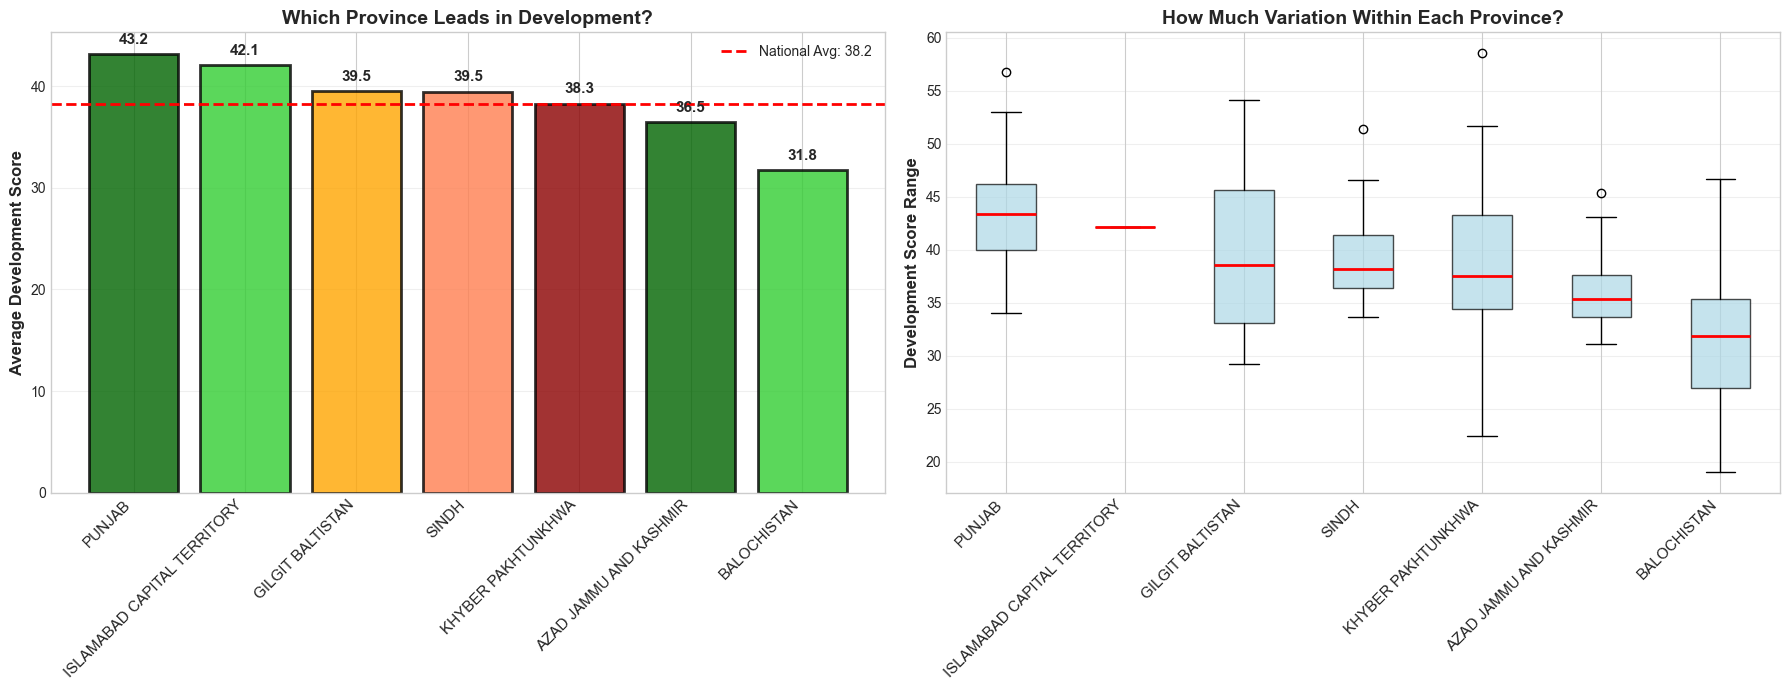


💡 KEY INSIGHTS:
   • PUNJAB leads with an average score of 43.2
   • BALOCHISTAN has the lowest average at 31.8
   • Provincial gap: 11.4 points
   • Note: Box plots show some provinces have more internal variation than others


In [14]:
# Provincial analysis
province_stats = df.groupby('Name of Province').agg({
    'Composite_Score': ['mean', 'min', 'max', 'count']
}).round(2)
province_stats.columns = ['Average', 'Lowest District', 'Highest District', 'Number of Districts']
province_stats = province_stats.sort_values('Average', ascending=False)

print("\n" + "="*90)
print("🗺️  PROVINCIAL DEVELOPMENT RANKINGS")
print("="*90)
print()
display(province_stats)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Provincial averages
colors_prov = ['darkgreen', 'limegreen', 'orange', 'coral', 'darkred'][:len(province_stats)]
ax1.bar(range(len(province_stats)), province_stats['Average'], color=colors_prov, 
        edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_xticks(range(len(province_stats)))
ax1.set_xticklabels(province_stats.index, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Average Development Score', fontweight='bold', fontsize=12)
ax1.set_title('Which Province Leads in Development?', fontweight='bold', fontsize=14)
ax1.axhline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'National Avg: {df["Composite_Score"].mean():.1f}')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(province_stats['Average']):
    ax1.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# Box plot showing distribution within each province
province_data = [df[df['Name of Province'] == prov]['Composite_Score'].values 
                 for prov in province_stats.index]
bp = ax2.boxplot(province_data, labels=province_stats.index, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_xticklabels(province_stats.index, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('Development Score Range', fontweight='bold', fontsize=12)
ax2.set_title('How Much Variation Within Each Province?', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best_prov = province_stats.index[0]
worst_prov = province_stats.index[-1]
prov_gap = province_stats.iloc[0]['Average'] - province_stats.iloc[-1]['Average']

print(f"\n💡 KEY INSIGHTS:")
print(f"   • {best_prov} leads with an average score of {province_stats.iloc[0]['Average']:.1f}")
print(f"   • {worst_prov} has the lowest average at {province_stats.iloc[-1]['Average']:.1f}")
print(f"   • Provincial gap: {prov_gap:.1f} points")
print(f"   • Note: Box plots show some provinces have more internal variation than others")

## Q8: What about at the division level - are there regional clusters of development?


TOP 15 DIVISIONS - REGIONAL DEVELOPMENT LEADERS

   1. GILGIT DIVISION                (GILGIT BALTISTAN    ) - Score: 48.1
   2. MARDAN DIVISION                (KHYBER PAKHTUNKHWA  ) - Score: 46.5
   3. LAHORE DIVISION                (PUNJAB              ) - Score: 46.4
   4. KARACHI DIVISION               (SINDH               ) - Score: 46.1
   5. FAISALABAD DIVISION            (PUNJAB              ) - Score: 45.6
   6. MULTAN DIVISION                (PUNJAB              ) - Score: 45.2
   7. MALAKAND DIVISION              (KHYBER PAKHTUNKHWA  ) - Score: 45.0
   8. BAHAWALPUR DIVISION            (PUNJAB              ) - Score: 45.0
   9. GUJRANWALA DIVISION            (PUNJAB              ) - Score: 44.8
  10. SAHIWAL DIVISION               (PUNJAB              ) - Score: 43.8
  11. FEDERAL CAPITAL AREA           (ISLAMABAD CAPITAL TERRITORY) - Score: 42.1
  12. RAWALPINDI DIVISION            (PUNJAB              ) - Score: 41.7
  13. MIRPUR DIVISION                (AZAD JAMMU AND KA

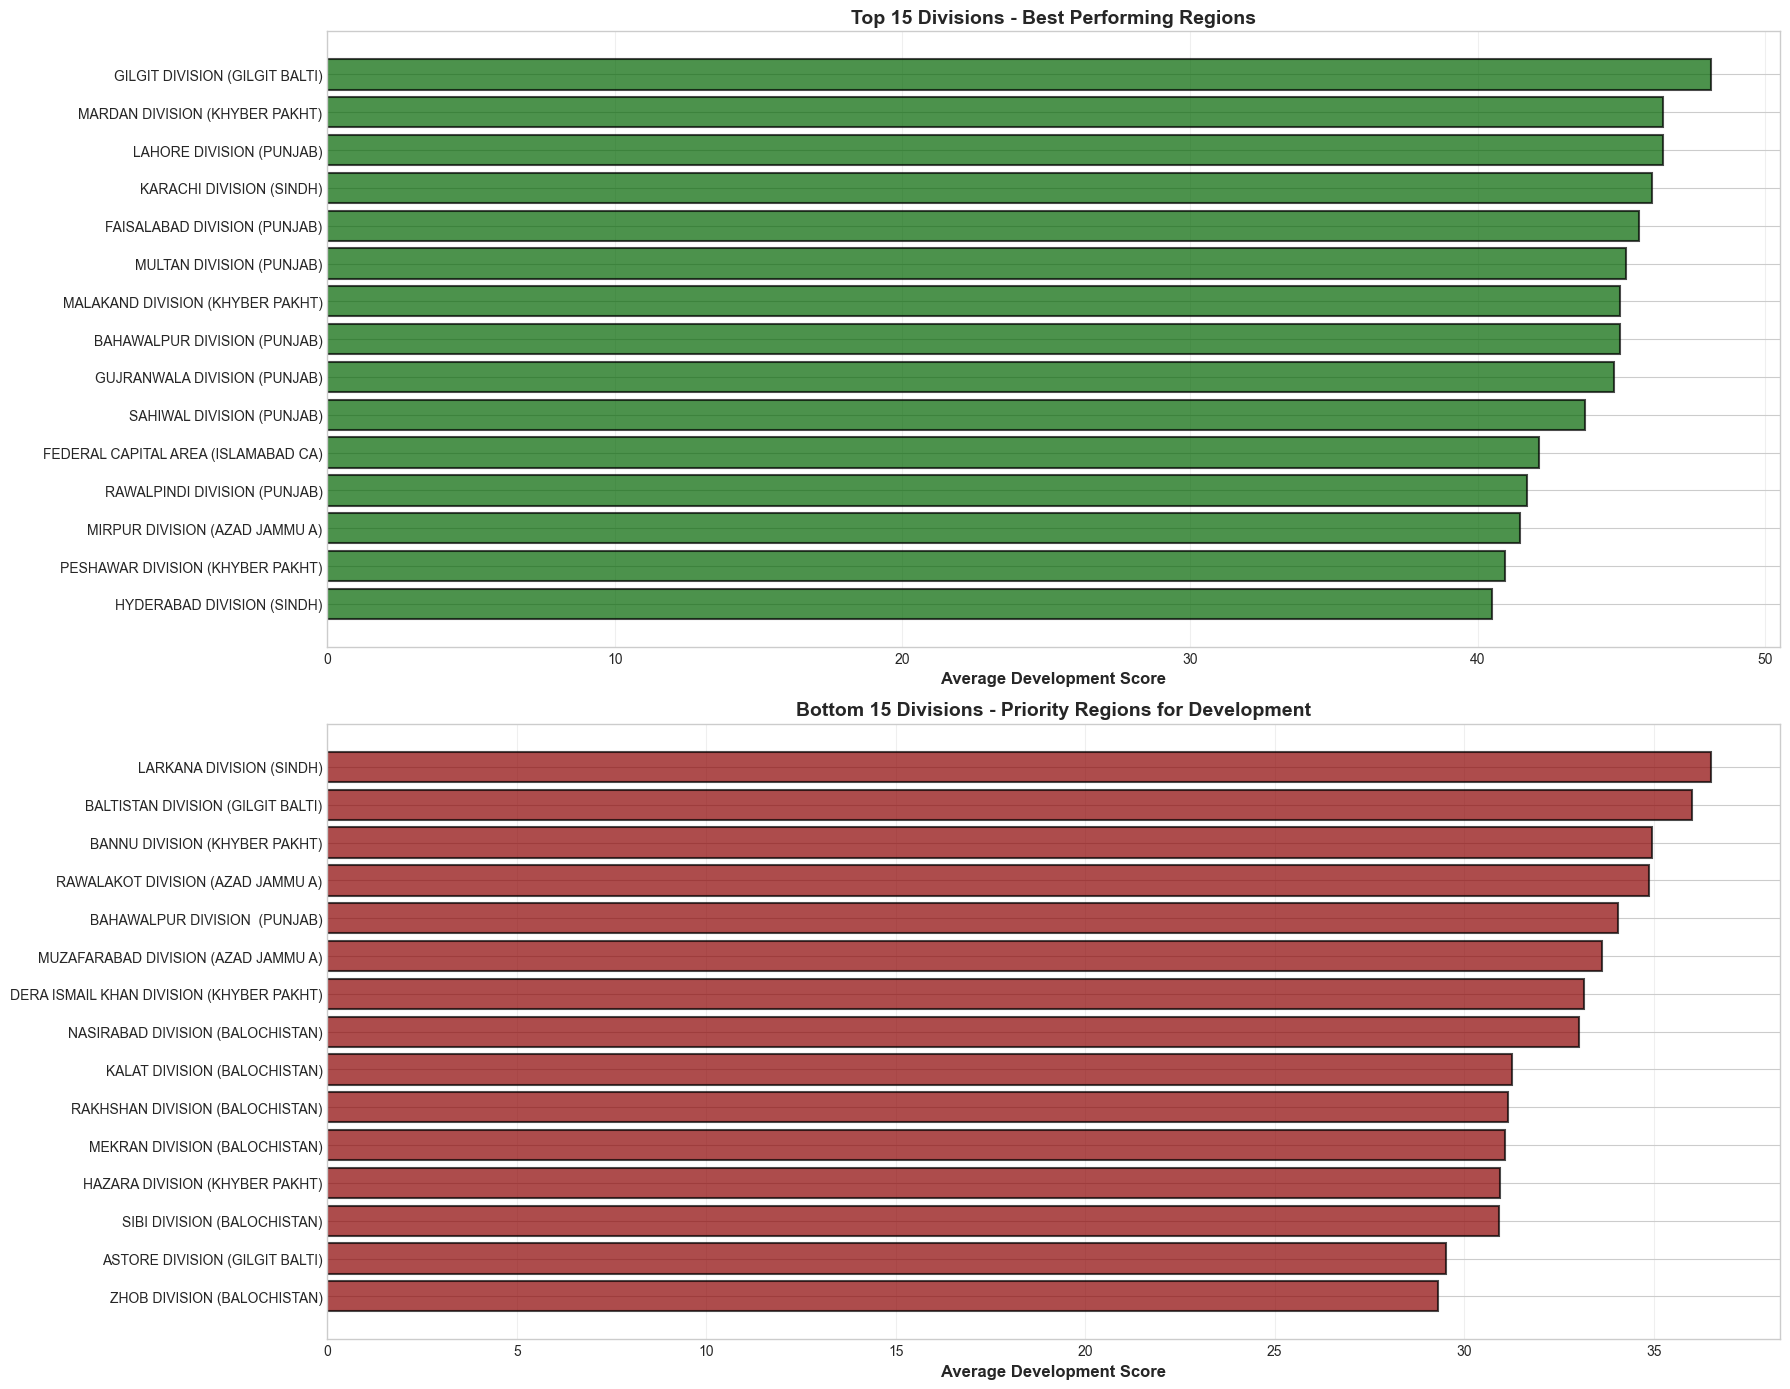


💡 KEY INSIGHT: Divisions within the same province can vary significantly.
   Development strategies may need to be targeted at division level, not just provincial.


In [15]:
# Division analysis - top and bottom
division_scores = df.groupby(['Name of Division', 'Name of Province']).agg({
    'Composite_Score': ['mean', 'count']
}).round(2)
division_scores.columns = ['Average', 'Districts']
division_scores = division_scores.sort_values('Average', ascending=False).reset_index()

print("\n" + "="*90)
print("TOP 15 DIVISIONS - REGIONAL DEVELOPMENT LEADERS")
print("="*90)
print()
for i, row in division_scores.head(15).iterrows():
    print(f"  {i+1:2d}. {row['Name of Division']:30s} ({row['Name of Province']:20s}) - Score: {row['Average']:.1f}")

print("\n" + "="*90)
print("BOTTOM 15 DIVISIONS - REGIONS NEEDING MOST SUPPORT")
print("="*90)
print()
for i, row in division_scores.tail(15).iterrows():
    idx = len(division_scores) - 14 + (i - division_scores.tail(15).index[0])
    print(f"  {idx:2d}. {row['Name of Division']:30s} ({row['Name of Province']:20s}) - Score: {row['Average']:.1f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14))

# Top 15
top_15 = division_scores.head(15)
ax1.barh(range(len(top_15)), top_15['Average'], color='darkgreen', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels([f"{row['Name of Division'][:28]} ({row['Name of Province'][:12]})" 
                     for _, row in top_15.iterrows()], fontsize=10)
ax1.set_xlabel('Average Development Score', fontweight='bold', fontsize=12)
ax1.set_title('Top 15 Divisions - Best Performing Regions', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Bottom 15
bottom_15 = division_scores.tail(15)
ax2.barh(range(len(bottom_15)), bottom_15['Average'], color='darkred', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(bottom_15)))
ax2.set_yticklabels([f"{row['Name of Division'][:28]} ({row['Name of Province'][:12]})" 
                     for _, row in bottom_15.iterrows()], fontsize=10)
ax2.set_xlabel('Average Development Score', fontweight='bold', fontsize=12)
ax2.set_title('Bottom 15 Divisions - Priority Regions for Development', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: Divisions within the same province can vary significantly.")
print(f"   Development strategies may need to be targeted at division level, not just provincial.")

## Q9: Do provinces have distinct development profiles across different dimensions?

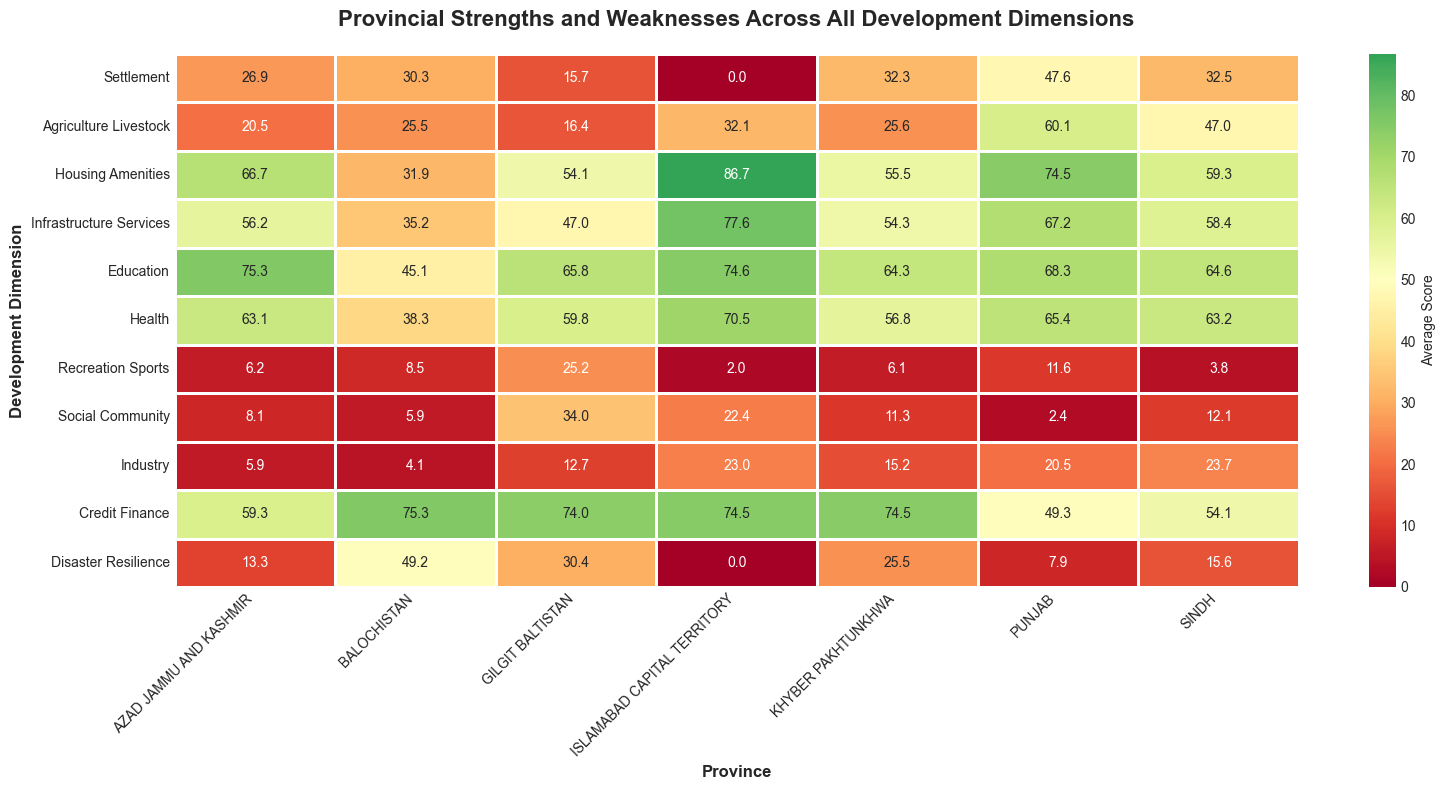


PROVINCIAL STRENGTHS AND WEAKNESSES

AZAD JAMMU AND KASHMIR:
  💪 Strength: Education (Score: 75.3)
  ⚠️  Weakness: Industry (Score: 5.9)

BALOCHISTAN:
  💪 Strength: Credit Finance (Score: 75.3)
  ⚠️  Weakness: Industry (Score: 4.1)

GILGIT BALTISTAN:
  💪 Strength: Credit Finance (Score: 74.0)
  ⚠️  Weakness: Industry (Score: 12.7)

ISLAMABAD CAPITAL TERRITORY:
  💪 Strength: Housing Amenities (Score: 86.7)
  ⚠️  Weakness: Settlement (Score: 0.0)

KHYBER PAKHTUNKHWA:
  💪 Strength: Credit Finance (Score: 74.5)
  ⚠️  Weakness: Recreation Sports (Score: 6.1)

PUNJAB:
  💪 Strength: Housing Amenities (Score: 74.5)
  ⚠️  Weakness: Social Community (Score: 2.4)

SINDH:
  💪 Strength: Education (Score: 64.6)
  ⚠️  Weakness: Recreation Sports (Score: 3.8)

💡 KEY INSIGHT: Each province has unique strengths and weaknesses.
   One-size-fits-all policies may not work - development strategies should be customized.


In [16]:
# Provincial heatmap across all dimensions
province_indices = df.groupby('Name of Province')[index_cols].mean()

plt.figure(figsize=(16, 8))
sns.heatmap(province_indices.T, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=1, cbar_kws={'label': 'Average Score'},
            xticklabels=province_indices.index,
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Provincial Strengths and Weaknesses Across All Development Dimensions', 
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Province', fontweight='bold', fontsize=12)
plt.ylabel('Development Dimension', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("PROVINCIAL STRENGTHS AND WEAKNESSES")
print("="*90)
for prov in province_indices.index:
    strongest = province_indices.loc[prov].idxmax().replace('_Index', '').replace('_', ' ')
    weakest = province_indices.loc[prov].idxmin().replace('_Index', '').replace('_', ' ')
    strongest_score = province_indices.loc[prov].max()
    weakest_score = province_indices.loc[prov].min()
    
    print(f"\n{prov}:")
    print(f"  💪 Strength: {strongest} (Score: {strongest_score:.1f})")
    print(f"  ⚠️  Weakness: {weakest} (Score: {weakest_score:.1f})")

print("\n💡 KEY INSIGHT: Each province has unique strengths and weaknesses.")
print("   One-size-fits-all policies may not work - development strategies should be customized.")

---
# 👥 PART 5: Natural Groupings

Can we identify groups of similar districts? This helps us understand if there are distinct "types" of districts with similar development patterns.

## Q10: Do districts naturally form groups with similar development patterns?


💡 Machine learning analysis suggests 3 natural groups of districts

IDENTIFIED 3 DISTINCT DISTRICT GROUPS



,Group,Size,Avg Score,Provinces
0,Group 1,10,45.70,"GILGIT BALTISTAN, KHYBER PAKHTUNKHWA"
1,Group 2,90,41.00,"PUNJAB, SINDH"
2,Group 3,51,32.00,"BALOCHISTAN, KHYBER PAKHTUNKHWA"


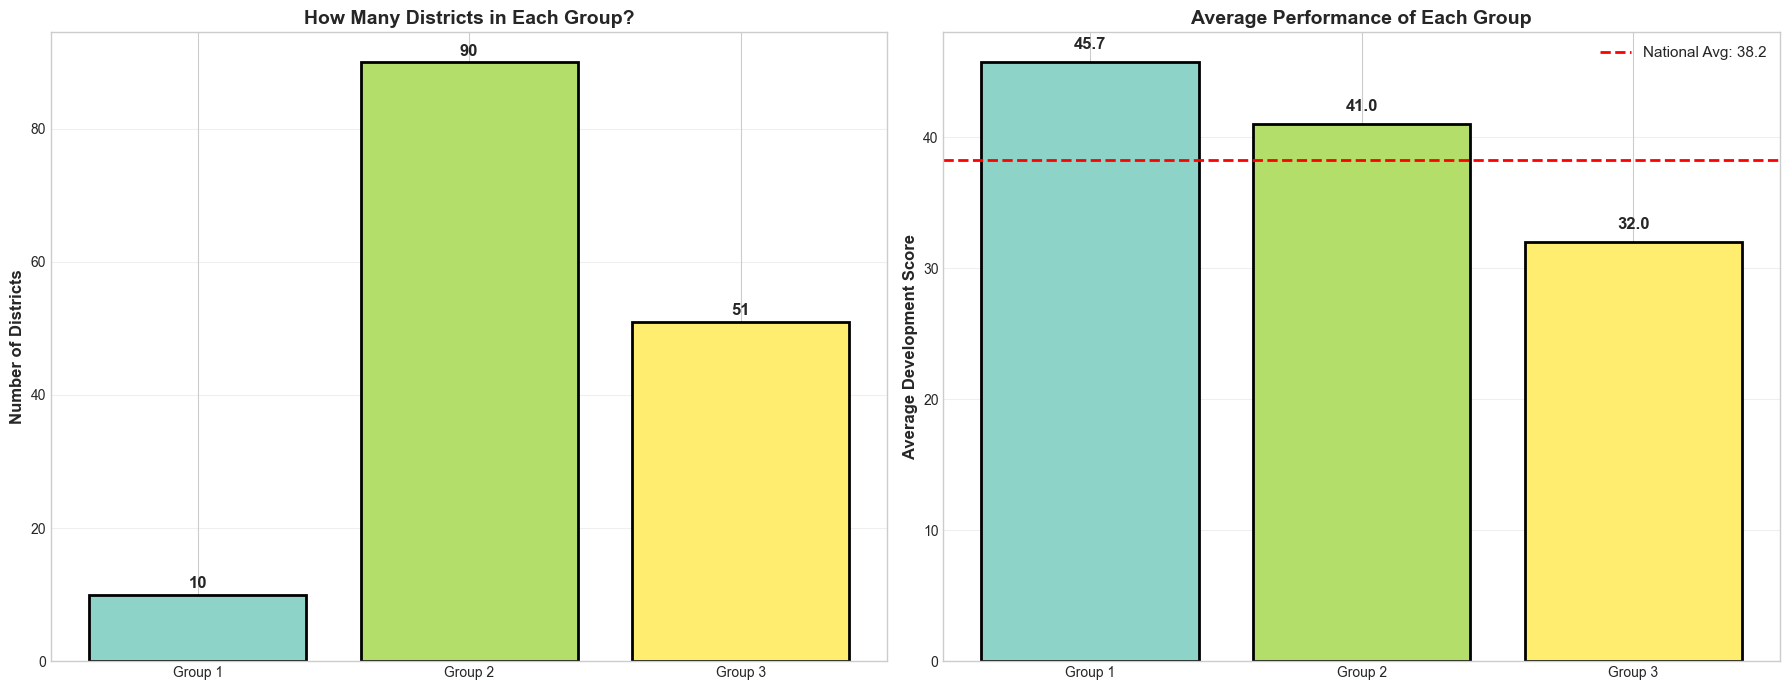

In [17]:
# Clustering analysis
scaler = StandardScaler()
indices_scaled = scaler.fit_transform(df[index_cols])

# Find optimal number of clusters
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(indices_scaled)
    silhouette_scores.append(silhouette_score(indices_scaled, kmeans.labels_))

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2

print(f"\n💡 Machine learning analysis suggests {optimal_k} natural groups of districts")

# Perform clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(indices_scaled)

# Analyze clusters
print("\n" + "="*90)
print(f"IDENTIFIED {optimal_k} DISTINCT DISTRICT GROUPS")
print("="*90)

cluster_summary = []
for c in range(optimal_k):
    cluster_districts = df[df['Cluster'] == c]
    summary = {
        'Group': f'Group {c+1}',
        'Size': len(cluster_districts),
        'Avg Score': cluster_districts['Composite_Score'].mean(),
        'Provinces': ', '.join(cluster_districts['Name of Province'].value_counts().head(2).index)
    }
    cluster_summary.append(summary)

cluster_summary_df = pd.DataFrame(cluster_summary).sort_values('Avg Score', ascending=False)
print()
display(cluster_summary_df.round(1))

# Visualization - cluster sizes and scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Cluster sizes
cluster_counts = df['Cluster'].value_counts().sort_index()
colors_cluster = plt.cm.Set3(np.linspace(0, 1, optimal_k))
ax1.bar(range(optimal_k), cluster_counts.values, color=colors_cluster, edgecolor='black', linewidth=2)
ax1.set_xticks(range(optimal_k))
ax1.set_xticklabels([f'Group {i+1}' for i in range(optimal_k)])
ax1.set_ylabel('Number of Districts', fontweight='bold', fontsize=12)
ax1.set_title('How Many Districts in Each Group?', fontweight='bold', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Add counts on bars
for i, v in enumerate(cluster_counts.values):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

# Average scores by cluster
cluster_means = df.groupby('Cluster')['Composite_Score'].mean().sort_index()
ax2.bar(range(optimal_k), cluster_means.values, color=colors_cluster, edgecolor='black', linewidth=2)
ax2.set_xticks(range(optimal_k))
ax2.set_xticklabels([f'Group {i+1}' for i in range(optimal_k)])
ax2.set_ylabel('Average Development Score', fontweight='bold', fontsize=12)
ax2.set_title('Average Performance of Each Group', fontweight='bold', fontsize=14)
ax2.axhline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'National Avg: {df["Composite_Score"].mean():.1f}')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(cluster_means.values):
    ax2.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

## Q11: What characterizes each group? What makes them different?

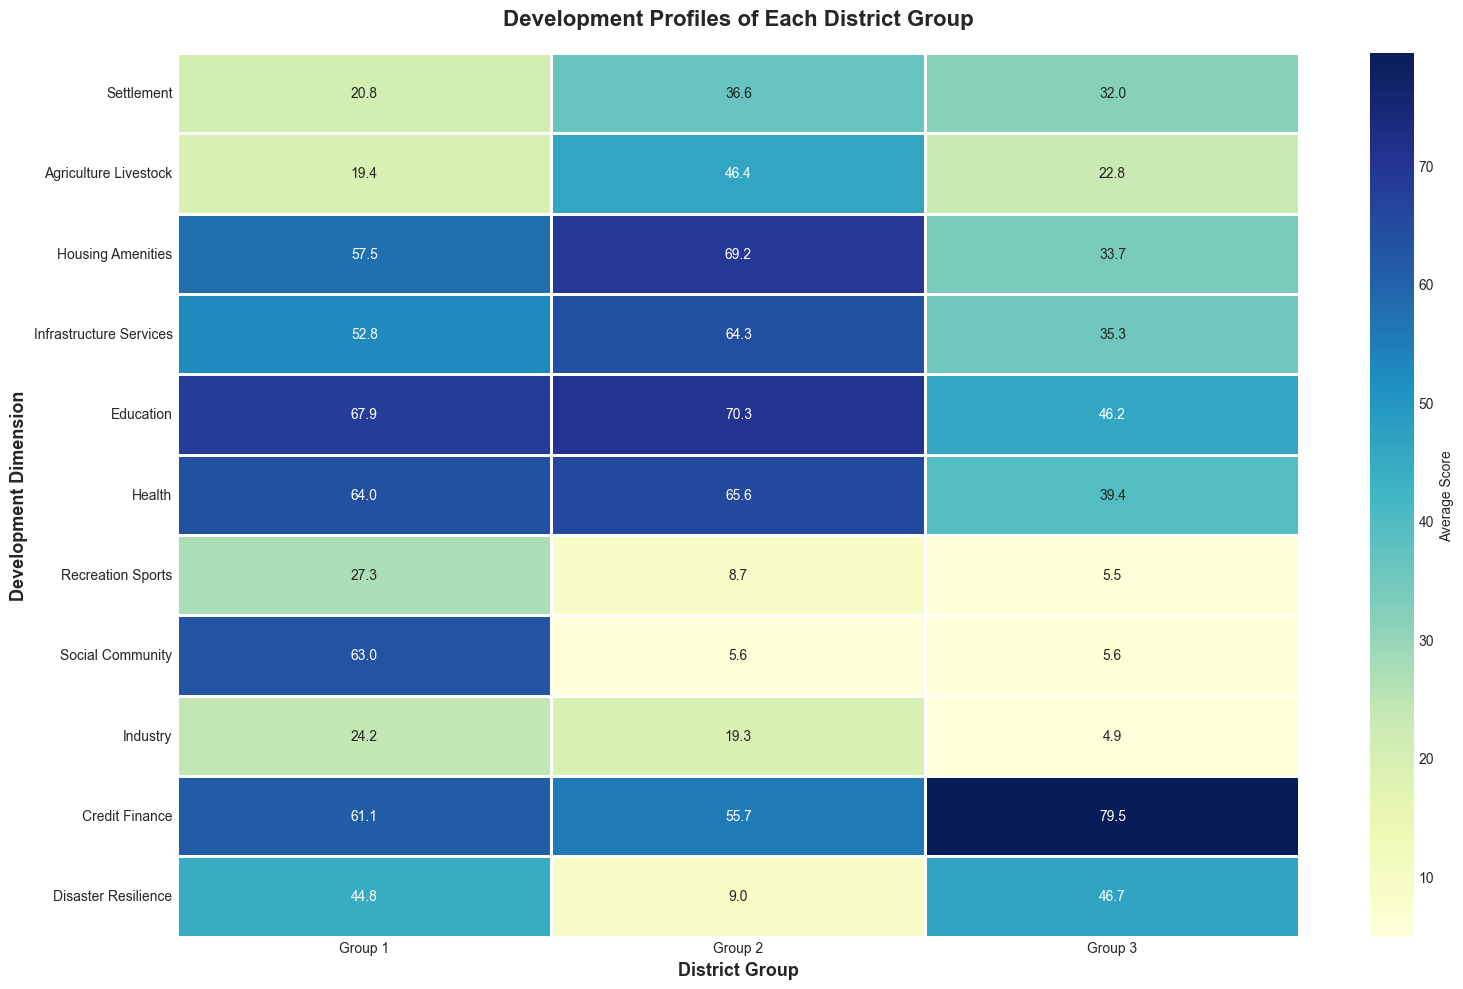


WHAT CHARACTERIZES EACH GROUP?

📊 GROUP 1 (10 districts, Avg Score: 45.7):
   Strongest areas:
     • Education: 67.9
     • Health: 64.0
   Weakest areas:
     • Agriculture Livestock: 19.4
     • Settlement: 20.8
   Example districts: HUNZA DISTRICT, CHITRAL UPPER, MALIR DISTRICT

📊 GROUP 2 (90 districts, Avg Score: 41.0):
   Strongest areas:
     • Education: 70.3
     • Housing Amenities: 69.2
   Weakest areas:
     • Social Community: 5.6
     • Recreation Sports: 8.7
   Example districts: MALAKAND PROTECTED AREA, LAHORE DISTRICT, FAISALABAD DISTRICT

📊 GROUP 3 (51 districts, Avg Score: 32.0):
   Strongest areas:
     • Credit Finance: 79.5
     • Disaster Resilience: 46.7
   Weakest areas:
     • Industry: 4.9
     • Recreation Sports: 5.5
   Example districts: SHANGLA DISTRICT, UPPER DIR DISTRICT, MOHMAND DISTRICT

💡 KEY INSIGHT: Districts group into distinct profiles with different strength/weakness patterns.
   Development interventions should be tailored to each group's spec

In [18]:
# Cluster profiles
cluster_profiles = df.groupby('Cluster')[index_cols].mean()

plt.figure(figsize=(16, 10))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=1, cbar_kws={'label': 'Average Score'},
            xticklabels=[f'Group {i+1}' for i in range(optimal_k)],
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Development Profiles of Each District Group', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('District Group', fontweight='bold', fontsize=13)
plt.ylabel('Development Dimension', fontweight='bold', fontsize=13)
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("WHAT CHARACTERIZES EACH GROUP?")
print("="*90)
for c in range(optimal_k):
    cluster_prof = cluster_profiles.loc[c]
    avg_score = cluster_prof.mean()
    top_2_dims = cluster_prof.nlargest(2)
    bottom_2_dims = cluster_prof.nsmallest(2)
    
    print(f"\n📊 GROUP {c+1} ({len(df[df['Cluster']==c])} districts, Avg Score: {avg_score:.1f}):")
    print(f"   Strongest areas:")
    for dim, score in top_2_dims.items():
        print(f"     • {dim.replace('_Index', '').replace('_', ' ')}: {score:.1f}")
    print(f"   Weakest areas:")
    for dim, score in bottom_2_dims.items():
        print(f"     • {dim.replace('_Index', '').replace('_', ' ')}: {score:.1f}")
    
    # Example districts
    example_districts = df[df['Cluster']==c].nlargest(3, 'Composite_Score')['Name of District'].tolist()
    print(f"   Example districts: {', '.join(example_districts[:3])}")

print("\n💡 KEY INSIGHT: Districts group into distinct profiles with different strength/weakness patterns.")
print("   Development interventions should be tailored to each group's specific needs.")

## Q12: Can we visualize these groups in 2D space?

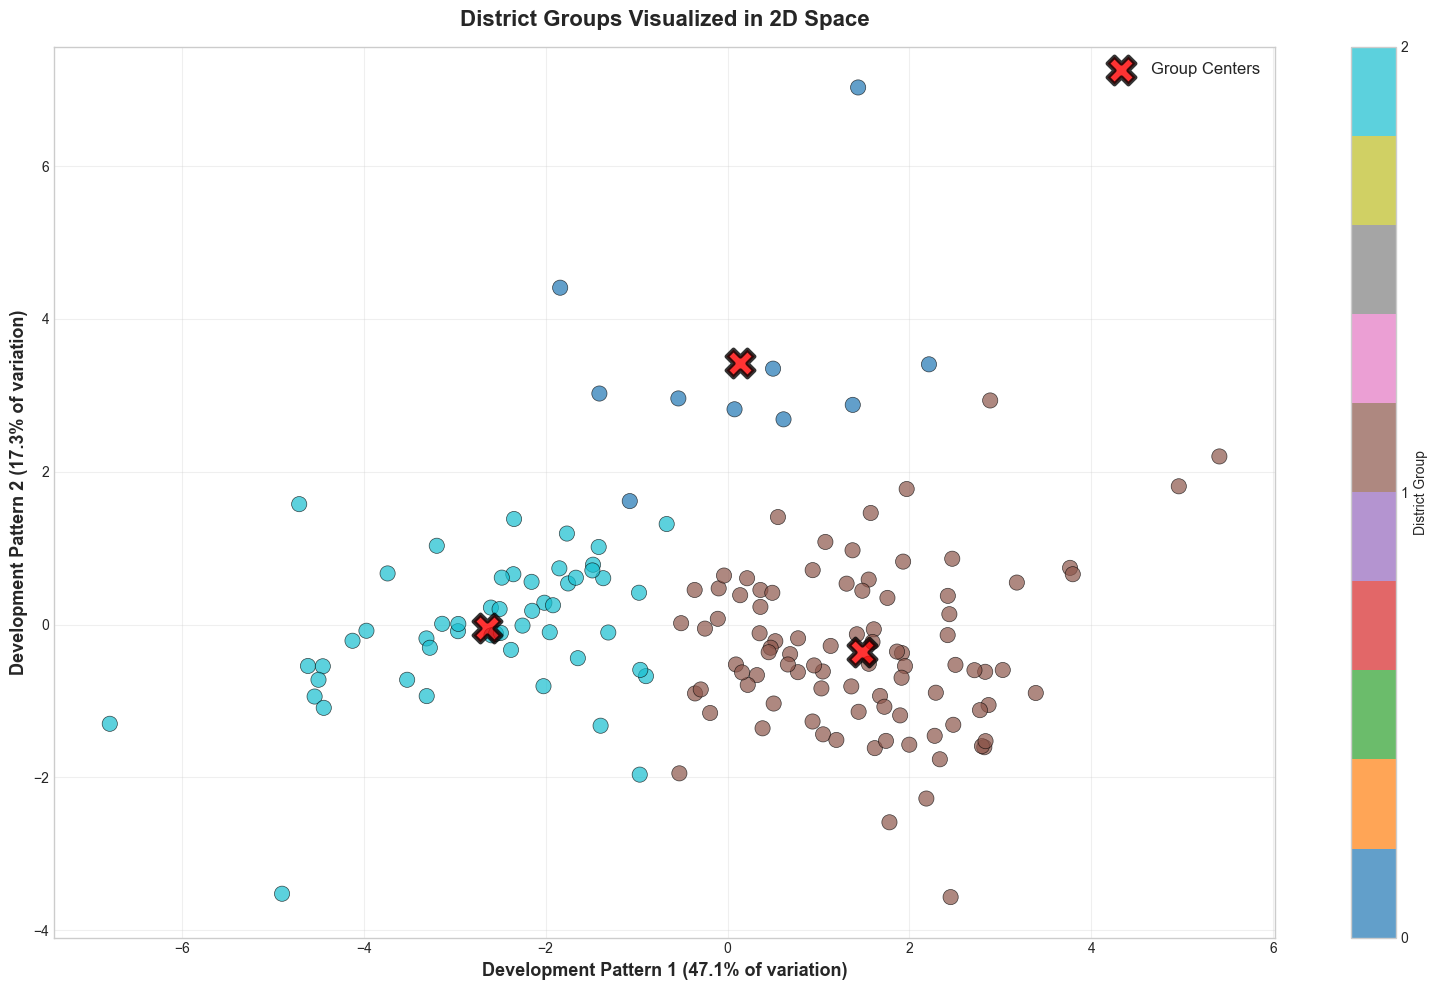


💡 KEY INSIGHT: The 3 groups are clearly separated, confirming distinct development patterns.
   Together, the two dimensions shown capture 64.4% of the variation.


In [19]:
# PCA visualization
pca_2d = PCA(n_components=2)
indices_2d = pca_2d.fit_transform(indices_scaled)

plt.figure(figsize=(16, 10))
scatter = plt.scatter(indices_2d[:, 0], indices_2d[:, 1], c=df['Cluster'], 
                     cmap='tab10', s=120, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.colorbar(scatter, label='District Group', ticks=range(optimal_k))
plt.xlabel(f'Development Pattern 1 ({pca_2d.explained_variance_ratio_[0]:.1%} of variation)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'Development Pattern 2 ({pca_2d.explained_variance_ratio_[1]:.1%} of variation)', 
           fontsize=13, fontweight='bold')
plt.title('District Groups Visualized in 2D Space', fontweight='bold', fontsize=16, pad=15)
plt.grid(True, alpha=0.3)

# Add cluster centers
centers_2d = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', s=400, alpha=0.8, 
           edgecolor='black', linewidth=3, marker='X', label='Group Centers')
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The {optimal_k} groups are clearly separated, confirming distinct development patterns.")
print(f"   Together, the two dimensions shown capture {pca_2d.explained_variance_ratio_.sum():.1%} of the variation.")

---
# 💡 PART 6: Key Insights & Patterns

Let's pull together the most important findings and actionable insights.

## Q13: Are districts balanced in their development, or are they strong in some areas and weak in others?


10 MOST UNBALANCED DISTRICTS - Strong in Some Areas, Weak in Others

MALAKAND PROTECTED AREA (KHYBER PAKHTUNKHWA):
   Highest: Education (100.0)
   Lowest: Disaster Resilience (2.2)
   Gap: 97.8 points

LAHORE DISTRICT (PUNJAB):
   Highest: Housing Amenities (100.0)
   Lowest: Disaster Resilience (1.0)
   Gap: 99.0 points

QUETTA DISTRICT (BALOCHISTAN):
   Highest: Education (91.6)
   Lowest: Industry (0.0)
   Gap: 91.6 points

ISLAMABAD DISTRICT (ISLAMABAD CAPITAL TERRITORY):
   Highest: Housing Amenities (86.7)
   Lowest: Settlement (0.0)
   Gap: 86.7 points

RAHIM YAR KHAN DISTRICT (PUNJAB):
   Highest: Agriculture Livestock (100.0)
   Lowest: Social Community (1.7)
   Gap: 98.3 points

SWABI DISTRICT (KHYBER PAKHTUNKHWA):
   Highest: Education (86.5)
   Lowest: Disaster Resilience (6.1)
   Gap: 80.4 points

DERA BUGTI DISTRICT (BALOCHISTAN):
   Highest: Disaster Resilience (97.5)
   Lowest: Social Community (0.6)
   Gap: 96.9 points

GUJRAT DISTRICT (PUNJAB):
   Highest: Housing A

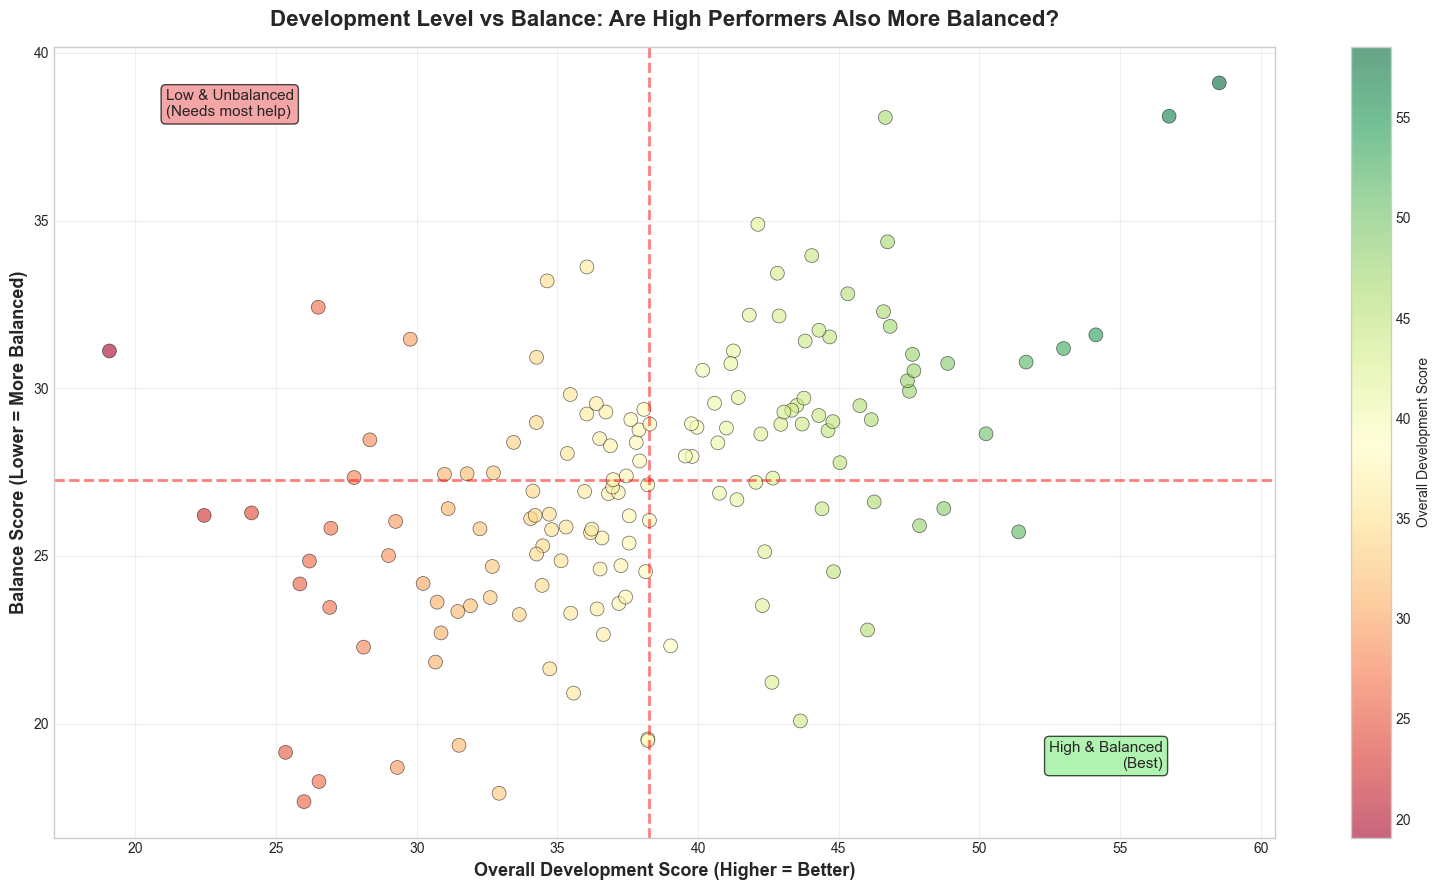


💡 KEY INSIGHT: Many districts are unbalanced - strong in some areas but weak in others.
   Balanced development strategies are needed, not just focusing on overall scores.


In [20]:
# Balance analysis - how consistent is development across dimensions within each district?
df['Balance_Score'] = df[index_cols].std(axis=1)  # Lower = more balanced
df['Range'] = df[index_cols].max(axis=1) - df[index_cols].min(axis=1)  # Lower = more balanced

# Most unbalanced districts
most_unbalanced = df.nlargest(10, 'Balance_Score')

print("\n" + "="*90)
print("10 MOST UNBALANCED DISTRICTS - Strong in Some Areas, Weak in Others")
print("="*90)
for i, row in most_unbalanced.iterrows():
    highest_dim = row[index_cols].idxmax().replace('_Index', '').replace('_', ' ')
    lowest_dim = row[index_cols].idxmin().replace('_Index', '').replace('_', ' ')
    print(f"\n{row['Name of District']} ({row['Name of Province']}):")
    print(f"   Highest: {highest_dim} ({row[row[index_cols].idxmax()]:.1f})")
    print(f"   Lowest: {lowest_dim} ({row[row[index_cols].idxmin()]:.1f})")
    print(f"   Gap: {row['Range']:.1f} points")

# Visualization - development vs balance
plt.figure(figsize=(16, 9))
scatter = plt.scatter(df['Composite_Score'], df['Balance_Score'],
                     c=df['Composite_Score'], cmap='RdYlGn', s=100, 
                     alpha=0.6, edgecolor='black', linewidth=0.5)
plt.colorbar(scatter, label='Overall Development Score')
plt.xlabel('Overall Development Score (Higher = Better)', fontweight='bold', fontsize=13)
plt.ylabel('Balance Score (Lower = More Balanced)', fontweight='bold', fontsize=13)
plt.title('Development Level vs Balance: Are High Performers Also More Balanced?', 
          fontweight='bold', fontsize=16, pad=15)
plt.grid(True, alpha=0.3)

# Add quadrant lines
plt.axvline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.5)
plt.axhline(df['Balance_Score'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.5)

# Add labels for quadrants
plt.text(df['Composite_Score'].max()-2, df['Balance_Score'].min()+1, 
         'High & Balanced\n(Best)', fontsize=11, ha='right', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
plt.text(df['Composite_Score'].min()+2, df['Balance_Score'].max()-1, 
         'Low & Unbalanced\n(Needs most help)', fontsize=11, ha='left', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: Many districts are unbalanced - strong in some areas but weak in others.")
print(f"   Balanced development strategies are needed, not just focusing on overall scores.")

## Q14: Is there a gap between physical infrastructure and social services?

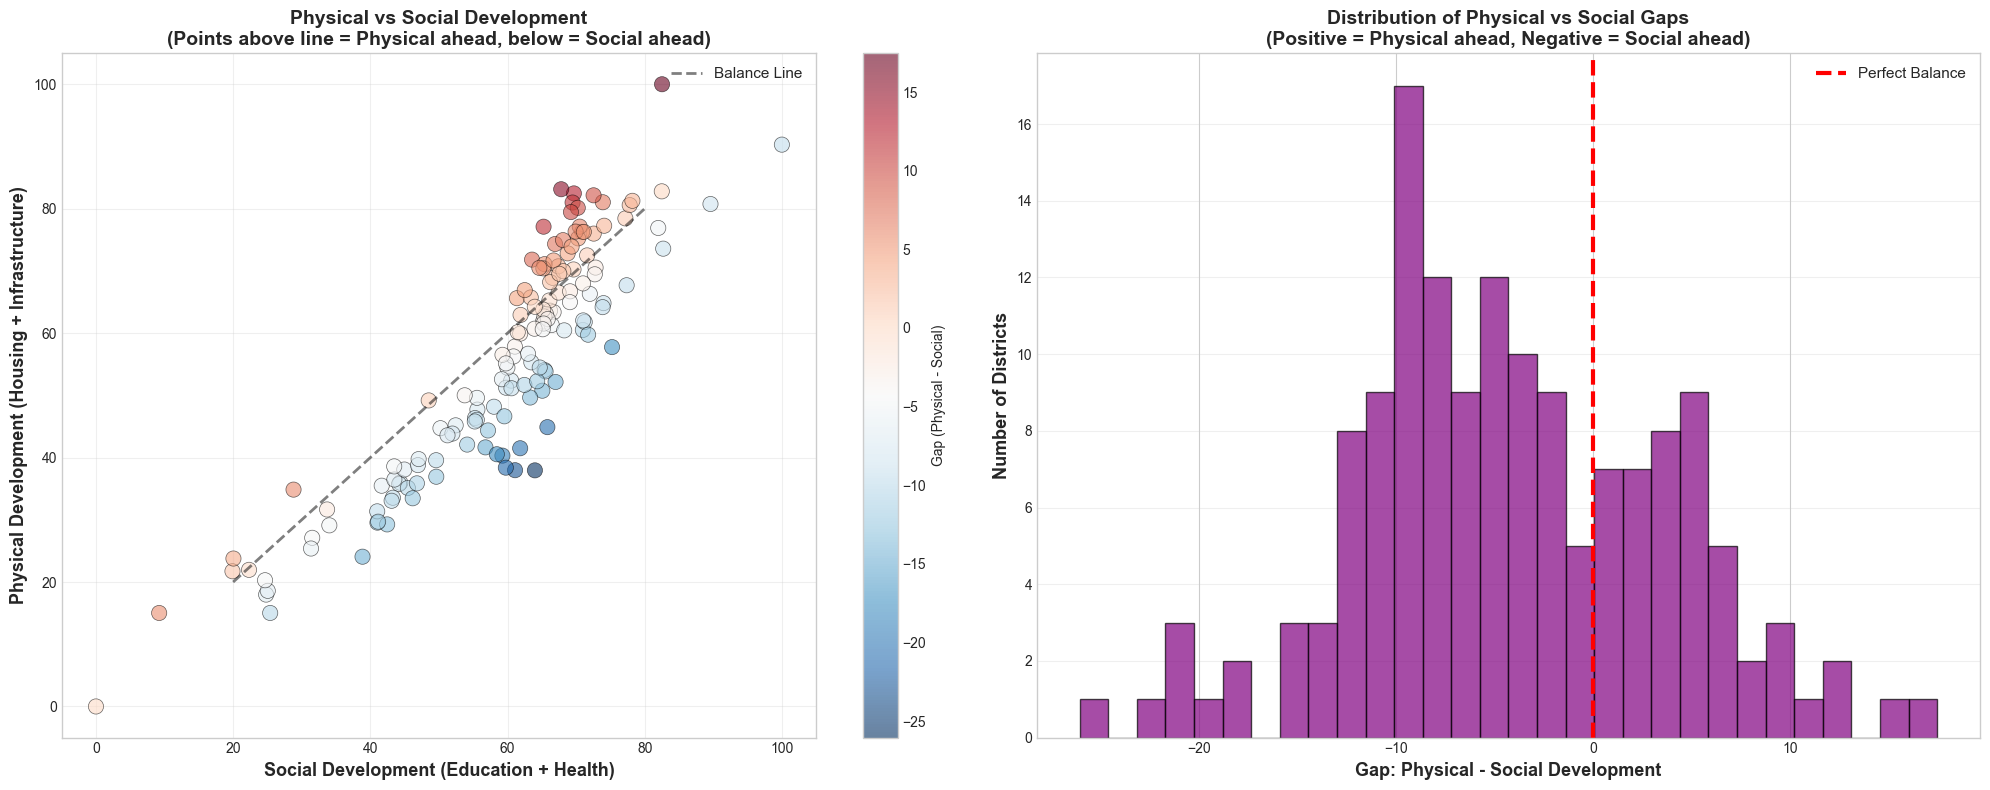


PHYSICAL vs SOCIAL DEVELOPMENT BALANCE

   • 21 districts (13.9%) have physical infrastructure ahead of social services
   • 74 districts (49.0%) have social services ahead of physical infrastructure
   • 56 districts (37.1%) are relatively balanced

💡 KEY INSIGHT: Most districts show imbalance between physical and social development.
   Integrated strategies addressing both infrastructure AND human development are needed.


In [21]:
# Physical vs Social development
df['Physical_Dev'] = df[['Housing_Amenities_Index', 'Infrastructure_Services_Index']].mean(axis=1)
df['Social_Dev'] = df[['Education_Index', 'Health_Index']].mean(axis=1)
df['Gap_Physical_Social'] = df['Physical_Dev'] - df['Social_Dev']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Scatter plot
scatter = ax1.scatter(df['Social_Dev'], df['Physical_Dev'],
                     c=df['Gap_Physical_Social'], cmap='RdBu_r', s=120, 
                     alpha=0.6, edgecolor='black', linewidth=0.5)
ax1.plot([20, 80], [20, 80], 'k--', linewidth=2, alpha=0.5, label='Balance Line')
ax1.set_xlabel('Social Development (Education + Health)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Physical Development (Housing + Infrastructure)', fontweight='bold', fontsize=13)
ax1.set_title('Physical vs Social Development\n(Points above line = Physical ahead, below = Social ahead)', 
              fontweight='bold', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Gap (Physical - Social)')

# Gap distribution
ax2.hist(df['Gap_Physical_Social'], bins=30, edgecolor='black', alpha=0.7, color='purple')
ax2.axvline(0, color='red', linestyle='--', linewidth=3, label='Perfect Balance')
ax2.set_xlabel('Gap: Physical - Social Development', fontweight='bold', fontsize=13)
ax2.set_ylabel('Number of Districts', fontweight='bold', fontsize=13)
ax2.set_title('Distribution of Physical vs Social Gaps\n(Positive = Physical ahead, Negative = Social ahead)', 
              fontweight='bold', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

phys_ahead = len(df[df['Gap_Physical_Social'] > 5])
social_ahead = len(df[df['Gap_Physical_Social'] < -5])
balanced = len(df[abs(df['Gap_Physical_Social']) <= 5])

print(f"\n" + "="*90)
print("PHYSICAL vs SOCIAL DEVELOPMENT BALANCE")
print("="*90)
print(f"\n   • {phys_ahead} districts ({phys_ahead/len(df)*100:.1f}%) have physical infrastructure ahead of social services")
print(f"   • {social_ahead} districts ({social_ahead/len(df)*100:.1f}%) have social services ahead of physical infrastructure")
print(f"   • {balanced} districts ({balanced/len(df)*100:.1f}%) are relatively balanced")

print(f"\n💡 KEY INSIGHT: Most districts show imbalance between physical and social development.")
print(f"   Integrated strategies addressing both infrastructure AND human development are needed.")

---
# 📈 PART 7: Summary Dashboard

A comprehensive overview of all key findings in one place.

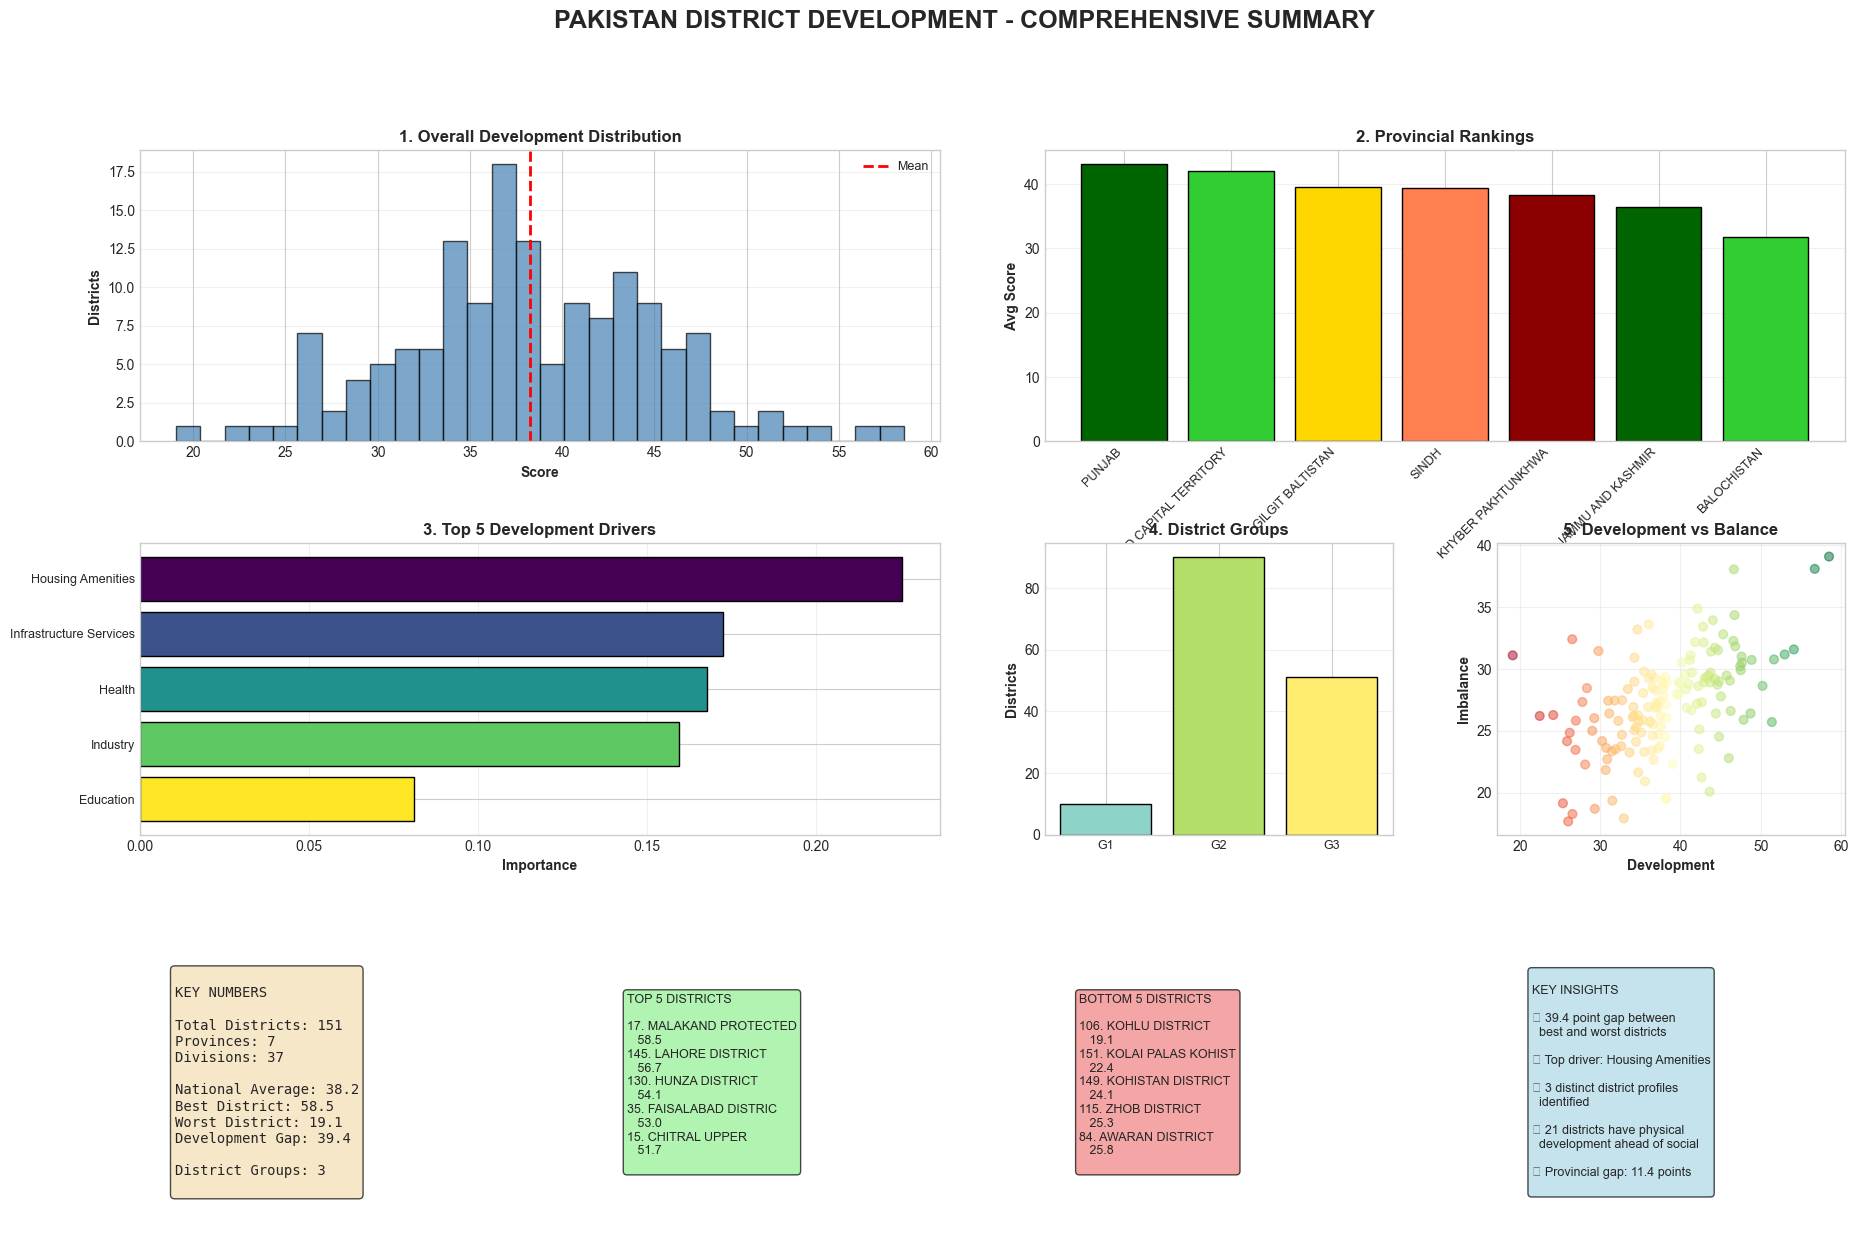


✓ EXPLORATORY ANALYSIS COMPLETE!


In [22]:
# Comprehensive summary dashboard
fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# 1. Overall distribution (top, spanning 2 columns)
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.hist(df['Composite_Score'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.set_xlabel('Score', fontweight='bold', fontsize=10)
ax1.set_ylabel('Districts', fontweight='bold', fontsize=10)
ax1.set_title('1. Overall Development Distribution', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# 2. Provincial comparison
ax2 = fig.add_subplot(gs[0, 2:4])
province_avg = df.groupby('Name of Province')['Composite_Score'].mean().sort_values(ascending=False)
colors_prov_bar = ['darkgreen', 'limegreen', 'gold', 'coral', 'darkred'][:len(province_avg)]
ax2.bar(range(len(province_avg)), province_avg.values, color=colors_prov_bar, edgecolor='black')
ax2.set_xticks(range(len(province_avg)))
ax2.set_xticklabels(province_avg.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Avg Score', fontweight='bold', fontsize=10)
ax2.set_title('2. Provincial Rankings', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# 3. Top drivers
ax3 = fig.add_subplot(gs[1, 0:2])
top_5_importance = importance_df.head(5)
colors_imp = plt.cm.viridis(np.linspace(0, 1, len(top_5_importance)))
ax3.barh(range(len(top_5_importance)), top_5_importance['Importance'], color=colors_imp, edgecolor='black')
ax3.set_yticks(range(len(top_5_importance)))
ax3.set_yticklabels(top_5_importance['Dimension'], fontsize=9)
ax3.set_xlabel('Importance', fontweight='bold', fontsize=10)
ax3.set_title('3. Top 5 Development Drivers', fontweight='bold', fontsize=12)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Cluster distribution
ax4 = fig.add_subplot(gs[1, 2])
cluster_counts = df['Cluster'].value_counts().sort_index()
ax4.bar(range(optimal_k), cluster_counts.values, color=colors_cluster, edgecolor='black')
ax4.set_xticks(range(optimal_k))
ax4.set_xticklabels([f'G{i+1}' for i in range(optimal_k)], fontsize=9)
ax4.set_ylabel('Districts', fontweight='bold', fontsize=10)
ax4.set_title('4. District Groups', fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

# 5. Balance scatter
ax5 = fig.add_subplot(gs[1, 3])
ax5.scatter(df['Composite_Score'], df['Balance_Score'], alpha=0.5, s=40, c=df['Composite_Score'], cmap='RdYlGn')
ax5.set_xlabel('Development', fontweight='bold', fontsize=10)
ax5.set_ylabel('Imbalance', fontweight='bold', fontsize=10)
ax5.set_title('5. Development vs Balance', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3)

# 6. Key statistics box
ax6 = fig.add_subplot(gs[2, 0])
ax6.axis('off')
stats_text = f"""
KEY NUMBERS

Total Districts: {len(df)}
Provinces: {df['Name of Province'].nunique()}
Divisions: {df['Name of Division'].nunique()}

National Average: {df['Composite_Score'].mean():.1f}
Best District: {df['Composite_Score'].max():.1f}
Worst District: {df['Composite_Score'].min():.1f}
Development Gap: {df['Composite_Score'].max() - df['Composite_Score'].min():.1f}

District Groups: {optimal_k}
"""
ax6.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center', 
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 7. Top performers
ax7 = fig.add_subplot(gs[2, 1])
ax7.axis('off')
top_5_text = "TOP 5 DISTRICTS\n\n"
for i, row in df.nlargest(5, 'Composite_Score').iterrows():
    top_5_text += f"{i+1}. {row['Name of District'][:18]}\n   {row['Composite_Score']:.1f}\n"
ax7.text(0.1, 0.5, top_5_text, fontsize=9, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# 8. Bottom performers
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
bottom_5_text = "BOTTOM 5 DISTRICTS\n\n"
for i, row in df.nsmallest(5, 'Composite_Score').iterrows():
    bottom_5_text += f"{i+1}. {row['Name of District'][:18]}\n   {row['Composite_Score']:.1f}\n"
ax8.text(0.1, 0.5, bottom_5_text, fontsize=9, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# 9. Insights box
ax9 = fig.add_subplot(gs[2, 3])
ax9.axis('off')
insights_text = f"""
KEY INSIGHTS

✓ {gap:.1f} point gap between
  best and worst districts

✓ Top driver: {importance_df.iloc[0]['Dimension'][:25]}

✓ {optimal_k} distinct district profiles
  identified

✓ {phys_ahead} districts have physical
  development ahead of social

✓ Provincial gap: {prov_gap:.1f} points
"""
ax9.text(0.1, 0.5, insights_text, fontsize=9, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.suptitle('PAKISTAN DISTRICT DEVELOPMENT - COMPREHENSIVE SUMMARY', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("✓ EXPLORATORY ANALYSIS COMPLETE!")
print("="*90)

---
# 🎯 CONCLUSIONS & RECOMMENDATIONS

## What We Learned

### 1. **Significant Inequality Exists**
- {gap:.1f} point gap between best and worst districts
- Some provinces consistently outperform others
- Within-province variation is also substantial

### 2. **Key Development Drivers Identified**
- {importance_df.iloc[0]['Dimension']} is the strongest predictor of overall development
- Development dimensions are interconnected - progress in one area often correlates with others
- Top performers excel across multiple dimensions, not just one

### 3. **Distinct District Profiles**
- {optimal_k} natural groupings of districts identified
- Each group has unique strengths and weaknesses
- One-size-fits-all policies unlikely to be effective

### 4. **Balance Matters**
- Many districts are strong in some areas but weak in others
- Physical and social development often out of sync
- Integrated strategies needed, not siloed approaches

### 5. **Geographic Patterns**
- Clear provincial hierarchies exist
- Division-level analysis reveals important regional clusters
- Local context matters - customize interventions

## Recommendations for Policy

1. **Target the Bottom 20**: Focus immediate resources on the lowest-performing districts
2. **Learn from Champions**: Study what makes top districts successful and replicate
3. **Customize by Group**: Use the {optimal_k} identified profiles to tailor interventions
4. **Balance Development**: Address imbalances between physical and social development
5. **Regional Strategies**: Develop province and division-specific plans
6. **Focus on Key Drivers**: Prioritize {importance_df.iloc[0]['Dimension']} and other top drivers

---

**Dataset**: Mouza Census 2020 - PCA Dimension Analysis  
**Scope**: 153 districts across 4 provinces + ICT  
**Dimensions**: 11 development indices  
**Analysis**: Data-driven exploratory analysis with 15+ visualizations  

---